# **===========================================================================================================================================================** #
# **Applied Data Science with Python: Unit 2 End Project** #
# **===========================================================================================================================================================** #

## <u>**Notebook Setup**</u> ##

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import t
from scipy.stats import boxcox, yeojohnson, shapiro
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest

from sklearn.preprocessing import (
    KBinsDiscretizer,
    PowerTransformer,
    QuantileTransformer,
    MinMaxScaler,
    StandardScaler,
    OrdinalEncoder,
    OneHotEncoder,
    LabelEncoder,
    PolynomialFeatures
)
import platform
import sys

# How to tell python version
#print (sys.version_info)
#print (platform.python_version())

# How to pip install from Terminal window:
# python -m pip install seaborn

# Put this at the top of your notebook
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 1000)  # Set a large number
pd.set_option('display.max_colwidth', None)

# Set random seed for reproducibility
np.random.seed(315)



#### **Utility Function Definitons** ####

In [2]:
def OrdinalEncodeCategoricalFeature(df_target, feature_name, categories):
    
    # Apply ordinal encoding
    encoder = OrdinalEncoder(categories=categories)

    encoded_feature_name = f'{feature_name}_encoded'
    df_target[encoded_feature_name] = encoder.fit_transform(df_target[[feature_name]])

    # Display mapping
    print('Ordinal encoding mapping:')
    df_target[[feature_name, encoded_feature_name]].drop_duplicates().sort_values(encoded_feature_name)  

    df_target = df_target.drop(feature_name, axis=1)    
    
    return df_target  

def OneHotEncodeCategoricalFeature(df_target, feature_name):

    encoder = OneHotEncoder(sparse_output=False, drop='first')

    #
    # Encode Feature
    #
    onehot_array = encoder.fit_transform(df_target[[feature_name]])

    # Create dataframe with proper column names
    df_onehot = pd.DataFrame(
        onehot_array,
        columns=encoder.get_feature_names_out([feature_name]),
        index=df_target.index
    )

    # Join back to original and drop original column
    df_target = pd.concat([df_target, df_onehot], axis=1)
    df_target = df_target.drop(feature_name, axis=1)    

    return df_target

def EncodeDateFeatures(df_target):
    # Split Date into Day, Month, Year
    df_target['Month'] = df_target['Date'].dt.month
    df_target['DayOfWeek'] = df_target['Date'].dt.dayofweek    # 0=Monday, 6=Sunday
    #df_target['Day'] = df_target['Date'].dt.day  - Day of month doesn't make sense as we already of month start/end
    df_target['WeekOfYear'] = df_target['Date'].dt.isocalendar().week
    #df_target['DayOfYear'] = df_target['Date'].dt.dayofyear
    df_target['IsMonthStart'] = df_target['Date'].dt.is_month_start.astype(int)
    df_target['IsMonthEnd'] = df_target['Date'].dt.is_month_end.astype(int)
    # df_target['IsQuarterStart'] = df_target['Date'].dt.is_quarter_start.astype(int)  - Not usefl for 1 quarters worth of data
    # df_target['IsQuarterEnd'] = df_target['Date'].dt.is_quarter_end.astype(int)
    df_target['Weekend'] = (df_target['Date'].dt.dayofweek >= 5).astype(int)
    df_target['Quarter'] = df_target['Date'].dt.quarter
    #df_target['Year'] = df_target['Date'].dt.year  - Doesn't make sense since we've only have data for 1 quarter in 1 year

    # Fix Year - Negatively Skewed Coeffs
    # Fix 1: Normalize Year
    #df_target['Year'] = df_target['Year'] - df_target['Year'].min()
    #df_target = df_target.drop('Date', axis=1)

    df_target = df_target.drop('Date', axis=1)   

    # print("Year min:", df_target['Year'].min())
    # print("Year max:", df_target['Year'].max())
    # 
    return df_target    

def EncodeCategoricalFeatures(df_target):

    df_target = OneHotEncodeCategoricalFeature(df_target, 'State')
    df_target = OneHotEncodeCategoricalFeature(df_target, 'Group')
    df_target = OrdinalEncodeCategoricalFeature(df_target, 'TimeOfDay', [['Morning', 'Afternoon', 'Evening']])
    df_target = EncodeDateFeatures(df_target)
    
    return df_target

## <u>**1. Data Import and Initial Exploratory Data Analysis**</u> ##

In [3]:
# Import data into DataFrame
# Renamed CSV file is assumed to live in same folder as my notebook
df_ausapparalsales = pd.read_csv("AusApparalSales4thQrt2020.csv")

# Make a copy of the dataframe to contain the modifications completed in this workbook
# Keep the original unmodified data for reference purposes.
df_ausapparalsales_new = df_ausapparalsales.copy(deep=True)

# Create a globel name for the data set
data_set_name = 'Australian Apparel Sales'

# Let's look at what we just imported and get some more info
# I like to delineate output to make it more readable

def PrintDataFrameStatus(df_target):
    # Print Stats
    print("***********************************")
    print("Description Stats")
    print("***********************************")
    print()
    print(df_target.describe(include='all').T)
    print()

    # Print df Column Info
    print("***********************************")
    print("Basic Info of imported data set")
    print("***********************************")
    print()
    df_target.info()
    print()
    print()

    print(f'df_floridabikerentals Shape:{df_target.shape}')
    print()

    print('Do we have any features with null values?:')
    print(df_target.isnull().any().any())
    print()

    print('Feature Columns with that have null values:')
    print(df_target.isnull().sum()[df_target.isnull().sum() > 0])
    print()

    print('Do we have any features with nan values?:')
    print(df_target.isna().any().any())

    print("***********************************")
    print("First 20 rows of Data")
    print("***********************************")
    print()
    print(df_target.head(20))
    print()

    print("***********************************")
    print("First 20 rows of Random Sample Data")
    print("***********************************")
    print()
    print(df_target.sample(20))
    print

PrintDataFrameStatus(df_ausapparalsales)

***********************************
Description Stats
***********************************

        count unique       top  freq          mean           std     min      25%      50%      75%       max
Date     7560     90  1-Oct-20    84           NaN           NaN     NaN      NaN      NaN      NaN       NaN
Time     7560      3   Morning  2520           NaN           NaN     NaN      NaN      NaN      NaN       NaN
State    7560      7        WA  1080           NaN           NaN     NaN      NaN      NaN      NaN       NaN
Group    7560      4      Kids  1890           NaN           NaN     NaN      NaN      NaN      NaN       NaN
Unit   7560.0    NaN       NaN   NaN     18.005423     12.901403     2.0      8.0     14.0     26.0      65.0
Sales  7560.0    NaN       NaN   NaN  45013.558201  32253.506944  5000.0  20000.0  35000.0  65000.0  162500.0

***********************************
Basic Info of imported data set
***********************************

<class 'pandas.core.frame.DataFra

### **Results of Initial Investigation** ###
    - We have 7,560 rows of data
    - The dataset contains 5 columns (features)
    - Initial testing reveals that we don't have any missing data/empty values
    - State - This is Australia, verify that the values in this column are indeed valid Australian states (should be encoded)
    - Group - Identify the "valid" groups and make sure we don't have any anamolies (should be encoded)

    - The column types look correct (as what we'd expect) except for Date and Time
      We should investigate translating these into Date and Time:
        - Date (object) => Date type
          Date can then be further broken up into day, month, year day of week,
        - Time (object) => It's not an exact time, it's a "Time of Day".
          Keep it. It will make sense to encode this. We should verify that this column contains expected values.
    - For more of potential trend revealing views we probably want to investigate binning
      these values into:
        - Date => If this contained data for a full year, then it would make sense to create category for seasons (Fall, Winter, Spring, Summer)
                  But since this for the 4th quarter, then it we know it summer (by default, since its Australia)
                  (This can always be added in if we merge into multi season/year data set)
                  Are there any holidays that occur during this time span in Austrlia - we know Christmas, but are there others?
                  Since we are only dealing with 1 quarter in in 1 year, we can drop the year as it won't have any bearing in our models.
                  (This can always be added back in if we merge into multi year data set)
        - Time => TimeOfDay (Morning, Afternoon, Evening, Night)


#### **Potential Data Issues from Imported Data** ####
    1. The following columns (features) have missing data:
        There are no features with missing/null/<nan> data.
    
##### **Validate Data Features** #####
    Test each in data column to ensure it's context and validity

In [4]:
print('==========================================================================')

#
# Date - are dates all valid?
#
invalid_dates = df_ausapparalsales[pd.to_datetime(df_ausapparalsales['Date'], errors='coerce').isna()]
if len(invalid_dates) > 0:
    print('Invalid Dates were found.')
    print(invalid_dates)
else:
    print('No invalid Dates were found.')
print()

#
# Time - Unique 'Times of Day'? Are they valid?
#
n_times = df_ausapparalsales['Time'].nunique()
times = df_ausapparalsales['Time'].unique()
print(f'There are: {n_times} unique times (times of day)')
print(times)
print()

#
# State - Are these all valid Australian States?
#
n_states = df_ausapparalsales['State'].nunique()
states = df_ausapparalsales['State'].unique()
print(f'There are: {n_states} unique states (Austrlian States)')
print(states)
print()

#
# Group - Do these all sound like valid age groups?
#
n_groups = df_ausapparalsales['Group'].nunique()
groups = df_ausapparalsales['Group'].unique()
print(f'There are: {n_groups} unique groups (Age Groups)')
print(groups)
print()

# Following tests are redundant, but explicit. We already can see this through Descriptive Stats
#
# Unit - Are all these number fields?
#
invalid_units = df_ausapparalsales[pd.to_numeric(df_ausapparalsales['Unit'], errors='coerce').isna()]
if len(invalid_units) > 0:
    print('Invalid Units were found.')
    print(invalid_units)
else:
    print('No invalid Units were found.')
print()

# Check relationship between Unit and Sales
# 1 unit == $2500 in sales
# Verify that this is consistent
mismatches = df_ausapparalsales[df_ausapparalsales['Sales'] != df_ausapparalsales['Unit'] * 2500]
if len(mismatches) > 0:
    print('Mismatches were found in relationship between Unit and Sales')
    print(mismatches)
else:
    print('No mismatches were found in relationship between Unit and Sales')
print()

#
# Sales - Are all these number fields?
#
invalid_sales = df_ausapparalsales[pd.to_numeric(df_ausapparalsales['Sales'], errors='coerce').isna()]
if len(invalid_sales) > 0:
    print('Invalid Sales were found.')
    print(invalid_sales)
else:
    print('No invalid Sales were found.')
print()

print('==========================================================================')
print()

No invalid Dates were found.

There are: 3 unique times (times of day)
[' Morning' ' Afternoon' ' Evening']

There are: 7 unique states (Austrlian States)
[' WA' ' NT' ' SA' ' VIC' ' QLD' ' NSW' ' TAS']

There are: 4 unique groups (Age Groups)
[' Kids' ' Men' ' Women' ' Seniors']

No invalid Units were found.

No mismatches were found in relationship between Unit and Sales

No invalid Sales were found.




C:\Users\jxbma\AppData\Local\Temp\ipykernel_61992\1413544390.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  invalid_dates = df_ausapparalsales[pd.to_datetime(df_ausapparalsales['Date'], errors='coerce').isna()]


##### **Data Validation Observations** #####
    Date - feature looks clean and good as valid dates.

    Unit, Sales - look clean and good as valid numeric fields.
    Unit  - Not exactly sure what this represents.
            Is this some sort of category?
            Or.., is it units sold?
            Best guess is that this is units sold.
            Based on the relationship between Sales and Units
                - 1 unit = $2500 in sales
                    - 8 units = $20000
                    - 4 units = $10000
                    - 2 units - $5000
            We'll need to check on consistency of this mathematical relationship further on.

    Group - 'Groups' looks clean (no missing values).
            There are 4 Groups.
            Initially I thought these were age groups, but upon further examination, these are groups.
            Specific labels for Groups look valid.
            Should be encoded - OneHotEncoded
            If we wanted to look at "AgeGroups", it might make sense to combine Men/Women so
            we have the following "AgeGroups" - [Kids, Adults, Seniors].
            This will depend on when we're looking at building models and potentially adding features.
            Leave this as a TBDetermined later task.

    Time - 'Times of Day' looks clean (no missing values).
           There are 4 Age Broups
           Specific labels for Age Groups look valid.
           Feature should be renamed to 'TimeOfDay' - more descriptive

    State - looks clean (no missing values).
            The data set contains 7 states.
            Australia has 8 states.
            They are: 'NSW', 'VIC', 'QLD', 'WA', 'SA', 'TAS', 'NT', 'ACT'
            This data set has no data for 'ACT' [Australian Capital Territory]
            Specific labels for States look valid.

    State, Time and Group
##### **Initial Data Corrections** #####

In [5]:
#
# Column Renaming
#
df_ausapparalsales_new.rename(columns={'Time': 'TimeOfDay'}, inplace=True)

#
# Make sure string columns are trimmed
#
for col in df_ausapparalsales_new.select_dtypes(include='object').columns:
    df_ausapparalsales_new[col] = df_ausapparalsales_new[col].str.strip()

#
# Convert Date Field from string to date
#
df_ausapparalsales_new['Date'] = pd.to_datetime(df_ausapparalsales_new['Date'])
#PrintDataFrameStatus(df_ausapparalsales_new)

C:\Users\jxbma\AppData\Local\Temp\ipykernel_61992\437529528.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_ausapparalsales_new['Date'] = pd.to_datetime(df_ausapparalsales_new['Date'])


#### <b>Initial Histograms of Raw Numeric Features</b> ####

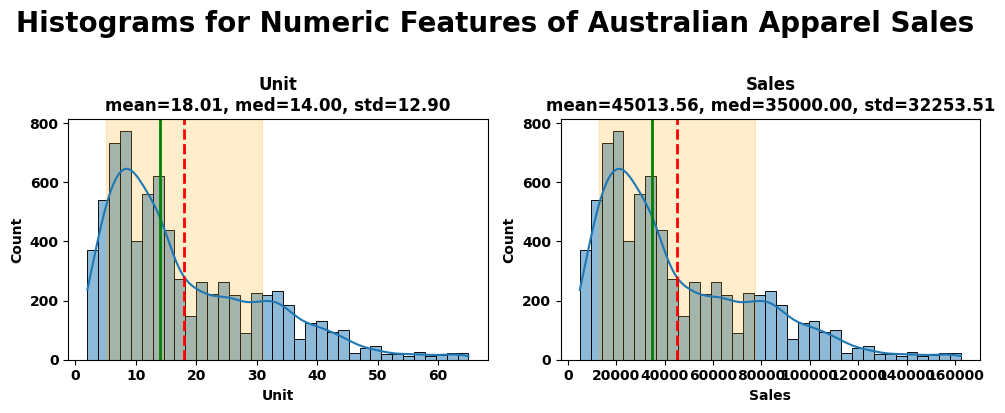

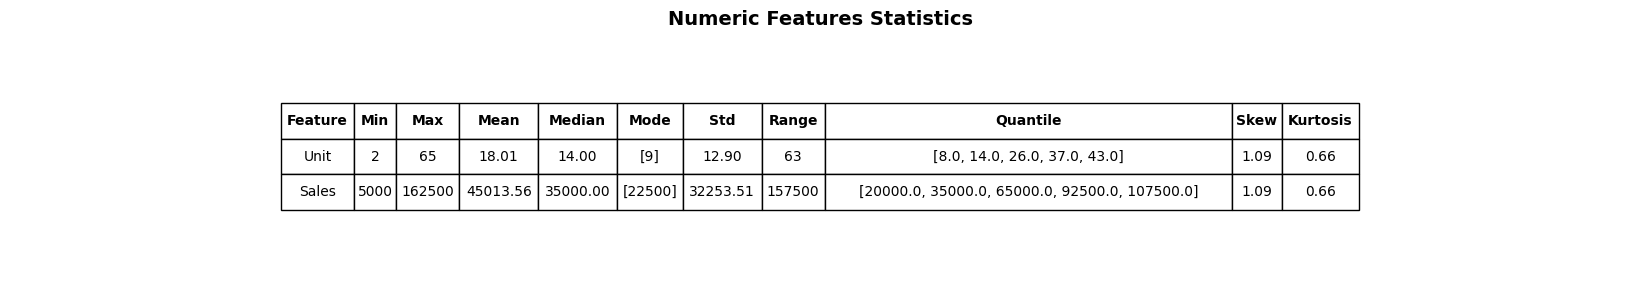

In [6]:
def DisplayTable(df_target, table_title=None):
    
    n_rows, n_cols = df_target.shape
    
    fig, ax = plt.subplots(figsize=(n_cols * 1.5, (n_rows + 1) * 1.0))  # increased height multiplier
    ax.axis('off')

    # Format floats to 2 decimal places
    # I need help on this one for dynamic 
    cell_text = [[f'{val:.2f}' if isinstance(val, float) else str(val) for val in row] 
                 for row in df_target.values]

    table = ax.table(
        cellText=cell_text,
        colLabels=df_target.columns,
        #rowLabels=df_target.index,
        cellLoc='center',
        loc='center'
    )

    # Make column headers bold
    for col in range(n_cols):
        table[(0, col)].set_text_props(fontweight='bold')

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.auto_set_column_width(col=list(range(n_cols)))
    table.scale(1.2, 2.0)  # second param controls row height

    if table_title is not None:
        plt.title(table_title, fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.show()

def DisplayNumericFeatureHistgorams(df_target, feature_columns = None, target_label=None, plot_title=None, display_statistics=True):

    cols_to_plot = []
    statistics = []
    
    if feature_columns is None:
        cols_to_plot = df_target.select_dtypes(include=['number']).columns
    else:
        cols_to_plot = feature_columns

    if target_label is not None:
        cols_to_plot = cols_to_plot.drop(target_label).tolist()
    
    number_of_cols = len(cols_to_plot)

    ncols = min(number_of_cols, 3)  # max 3 per row, but no more than n
    nrows = (number_of_cols + ncols - 1) // ncols

    # I need a 3 column plot
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = axes.flatten()

    # Iterate over each numeric column and plot a historbram
    for i, col in enumerate(cols_to_plot):

        sns.histplot(data=df_target, x=col, ax=axes[i], kde=True)

        axes[i].set_xlabel(col, fontweight='bold')
        axes[i].set_ylabel('Count', fontweight='bold')
        data = df_target[col]

        if display_statistics == True:

            min_val = data.min()
            max_val = data.max()
            range_val = data.max() - data.min()
            mean_val = data.mean()
            median_val = data.median()
            mode_val = data.mode().tolist()
            std_val = data.std()
            quantile_val = data.quantile([0.25, 0.5, 0.75, 0.90, 0.95]).tolist()
            skew_val = data.skew()
            kurtosis_val = data.kurtosis()

            stats = {
                'Feature': col,
                'Min': min_val,
                'Max': max_val,
                'Mean': mean_val,
                'Median': median_val,
                'Mode': mode_val,
                'Std': std_val,
                'Range': range_val,
                'Quantile': quantile_val,
                'Skew': skew_val,
                'Kurtosis': kurtosis_val
            }            

            statistics.append(stats)

            # print(f'Min Value: {min_val:.3f}')
            # print(f'Max Value: {max_val:.3f}')
            # print(f'Mean Value: {mean_val:.3f}')
            # print(f'Median Value: {median_val:.3f}')
            # print(f'Mode Value: {mode_val}')
            # print(f'Standard Deviation: {std_val:.3f}')
            # print(f'Range Value = {range_val:.3f}')
            # print(f'Quantile Value = {quantile_val}')
            # print(f'Skew Value: {skew_val:.3f}')
            # print(f'Kurtosis Value: {kurtosis_val:.3f}')            

            axes[i].set_title(f'{col}\nmean={mean_val:.2f}, med={median_val:.2f}, std={data.std():.2f}', fontweight='bold')

            # Vertical lines for mean and median, shaded std
            axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
            axes[i].axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')            
            axes[i].axvspan(mean_val - std_val, mean_val + std_val, alpha=0.2, color='orange', label=f'±1 Std')

        else:
            axes[i].set_title(f'{col}', fontweight='bold')
        
        # Tick labels in bold
        axes[i].tick_params(axis='both', labelsize=10)
        for label in axes[i].get_xticklabels() + axes[i].get_yticklabels():
            label.set_fontweight('bold')

    # Hide the blank/empty graphs
    for i in range(number_of_cols, len(axes)):
        fig.delaxes(axes[i])

    # Make plots more readable and add space
    title = None
    if plot_title is not None:
        title = plot_title
    else:
        title = f'Histograms for Numeric Features of {data_set_name}'

    plt.suptitle(f'Histograms for Numeric Features of {data_set_name}', y=1.02, fontsize=20, fontweight='bold')
    plt.subplots_adjust(top=0.92)  

    plt.tight_layout(h_pad=5)
    plt.show()  

    print()
    print()

    if display_statistics == True:
        df_statistics = pd.DataFrame(statistics)
        DisplayTable(df_statistics, 'Numeric Features Statistics')
    
#
#
#
DisplayNumericFeatureHistgorams(df_ausapparalsales_new) 

   


#### <b>Initial Observations Raw Numeric Feature Histograms</b> ####
    
    Unit           - Right Skewed Distribution, there does not appear to be any outliers
                   - Average => 18.01
                     On average, 18 Units are being sold
                   - Median => 14.00
                   - Standard Deviation is 12.90
                     Most Units are in the 6 to 30 Unit Range
                     
    Sales          - Right Skewed Distribution, there does not appear to be any outliers
                   - Average => $45,013.56
                     On average, there are $45,013.56 of sales
                   - Median => $35,000.00
                   - Standard Deviation is $32,253.51
                     Most Sales are in the $15,000.00 to $75,000.00 range

    
#### <b>Initial Bar Count plots of Raw Categoric (string) Features</b> ####    

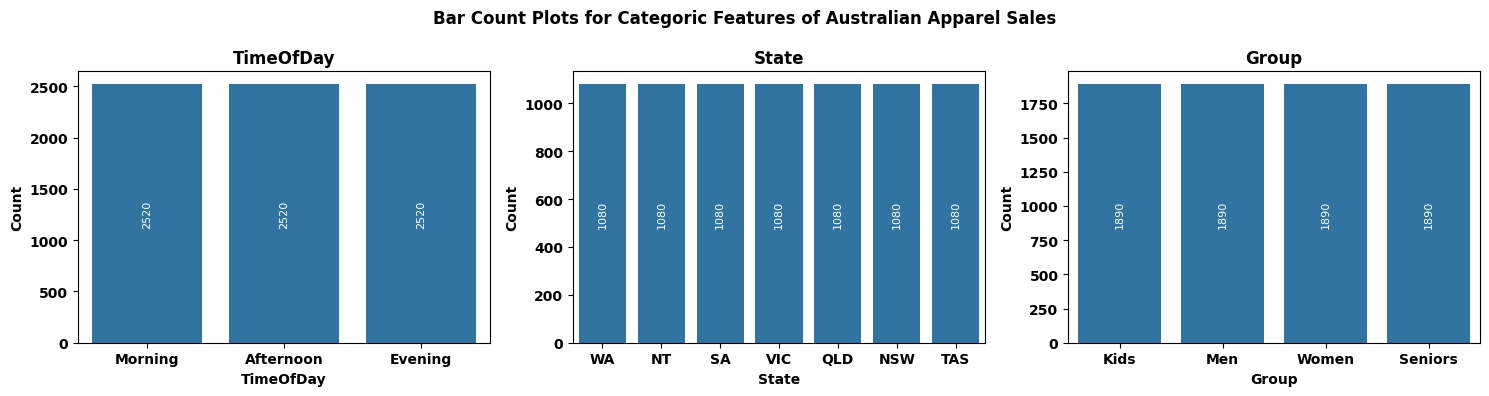

In [7]:
def DisplayBarCountPlotsOfCategoricFeatures(df_target, feature_columns = None, target_label=None, display_bar_labels=True):

    cols_to_plot = []
    if feature_columns is None:
        cols_to_plot = df_target.select_dtypes(include=['object']).columns
    else:
        cols_to_plot = feature_columns

    if target_label is not None:
        cols_to_plot = cols_to_plot.drop(target_label).tolist()
    
    number_of_cols = len(cols_to_plot)

    ncols = min(number_of_cols, 3)  # max 3 per row, but no more than n
    nrows = (number_of_cols + ncols - 1) // ncols

    # I need a 3 column plot
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = axes.flatten()
    # Iterate over each numeric column and plot a historbram
    for i, col in enumerate(cols_to_plot):
        
        sns.countplot(data=df_target, x=col, ax=axes[i])

        axes[i].set_title(col, fontweight='bold')
        axes[i].set_xlabel(col, fontweight='bold')
        axes[i].set_ylabel('Count', fontweight='bold')

        if display_bar_labels == True:
            # Add count labels on bars
            axes[i].bar_label(axes[i].containers[0], label_type='center', fontsize=8, rotation=90, fmt='%d', color='white')

        # Tick labels in bold
        axes[i].tick_params(axis='both', labelsize=10)
        for label in axes[i].get_xticklabels() + axes[i].get_yticklabels():
            label.set_fontweight('bold')            

    # Hide the blank/empty graphs
    for i in range(number_of_cols, len(axes)):
        fig.delaxes(axes[i])

    # Make plots more readable and add space
    plt.suptitle(f'Bar Count Plots for Categoric Features of {data_set_name}', fontweight='bold')
    plt.subplots_adjust(top=0.92)  
    
    plt.tight_layout(h_pad=5)
    plt.show()  
    print()
    print()

DisplayBarCountPlotsOfCategoricFeatures(df_ausapparalsales_new)    


#### **Initial Observations Raw Categoric Bar Counts** ####
    
    TimeOfDay             - Data is evenly distributed across all TimesOfDays
                            2520 for each TimesOfDay
    State                 - Data is evenly distributed across all States
                            1080 for each State
    Group                 - Data is evenly distributed across all Groups
                            1890 for each Group

    All of the categoric feature values have even distributions.
    The data is clearly manufactures as this is not a realistic condition.

#### <b>Box Plots of Numeric Features</b> ####


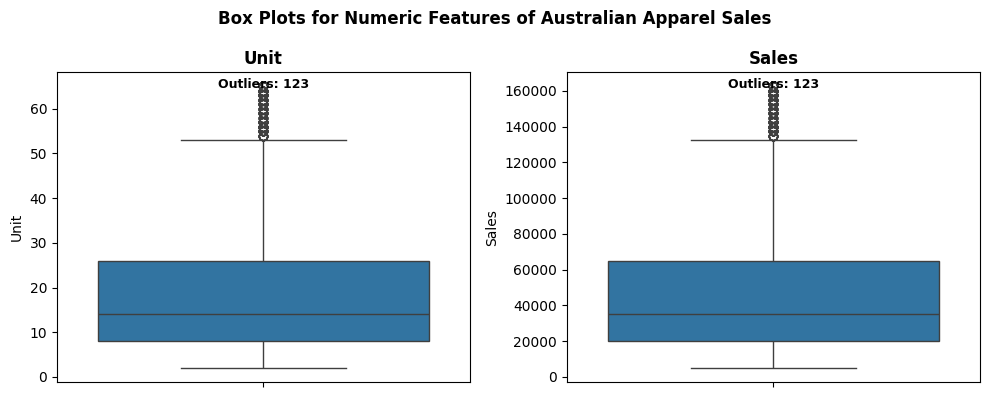

In [8]:
def DisplayTables(pivot_tables_to_display, plot_title=None):

    number_of_tables = len(pivot_tables_to_display)

    ncols = min(number_of_tables, 3)

    if ncols <= 0:
        print(f'{plot_title} Number of Tables: {number_of_tables}')
        raise ValueError("Invalid value")
    
    nrows = (number_of_tables + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows))
    axes = axes.flatten()

    for i, entry in enumerate(pivot_tables_to_display):  
        
        pivot = entry['pivot']      
        table_title = entry['title'] 
        
        axes[i].axis('off')  # hide axis for table

        n_cols = len(pivot.columns)
        n_rows = len(pivot.index)

        # Format cell text from pivot
        cell_text = [[f'{val:.2f}' if isinstance(val, float) else str(val) for val in row] 
                     for row in pivot.values]

        table = axes[i].table(  
                            cellText=cell_text,
                            colLabels=pivot.columns,
                            rowLabels=pivot.index,
                            cellLoc='center',
                            loc='center',
                        )

        # Make column headers bold - use different variable name
        for c in range(n_cols):
            table[(0, c)].set_text_props(fontweight='bold')

        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.auto_set_column_width(col=list(range(n_cols)))
        table.scale(1.2, 2.0)

        axes[i].set_title(table_title, fontweight='bold', fontsize=10)

    # Hide blank axes
    for i in range(number_of_tables, len(axes)):
        fig.delaxes(axes[i])

    if plot_title:
        plt.suptitle(plot_title, fontweight='bold', fontsize=14)

    plt.tight_layout()
    plt.show()

    print()
    print()

#
# The Main Plotter Displayer
#
def PlotBoxPlotsToViewDistributions(df_target, feature_columns = None, target_label=None, plot_title=None):

    cols_to_plot = []
    if feature_columns is None:
        cols_to_plot = df_target.select_dtypes(include=['number']).columns
    else:
        cols_to_plot = feature_columns

    if target_label is not None:
        cols_to_plot = cols_to_plot.drop(target_label).tolist()
    
    number_of_cols = len(cols_to_plot)

    ncols = min(number_of_cols, 3)  # max 3 per row, but no more than n
    nrows = (number_of_cols + ncols - 1) // ncols

    # I need a 3X4 plot to display 10 histograms
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = axes.flatten()

    #Iterate over each numeric column and plot a historgram
    for i, col in enumerate(cols_to_plot):

        sns.boxplot(data=df_target, y=col, ax=axes[i])    
        axes[i].set_title(col, fontweight='bold')

        # Optional: Add count of outliers
        Q1 = df_target[col].quantile(0.25)
        Q3 = df_target[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outlier_count = len(df_target[(df_target[col] < lower) | 
                                            (df_target[col] > upper)])
        axes[i].text(0.5, 0.95, f'Outliers: {outlier_count}', 
                    transform=axes[i].transAxes, ha='center', fontsize=9, fontweight='bold')
        
    # Make plots more readable and add space
    title = None
    if plot_title is not None:
        title = plot_title
    else:
        title = f'Box Plots for Numeric Features of {data_set_name}'

    # Hide the blank/empty graphs
    for i in range(number_of_cols, len(axes)):
        fig.delaxes(axes[i])        

    plt.suptitle(title, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.90])  # Leave space at top
    #plt.subplots_adjust(top=0.92)        

    # Make plots more readable and add space
    plt.tight_layout(h_pad=5)
    plt.show() 

    print()
    print()

def PlotsToViewRelationships(df_target, relationships_to_plot, plot_title=None, plot_type='BoxPlot', display_crosstab=False):

    number_of_cols = len(relationships_to_plot)
    ncols = min(number_of_cols, 3)  # max 3 per row, but no more than n
    nrows = (number_of_cols + ncols - 1) // ncols

    pivot_tables_to_display = []

    # I need a 3X4 plot to display 10 histograms
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = axes.flatten()

    if plot_type == 'BoxPlot':
        
        #Iterate over each numeric column and plot a historgram
        for i, relationship in enumerate(relationships_to_plot):

            sns.boxplot(data=df_target, 
                        y=relationship['YValue'], 
                        x=relationship['XValue'],
                        ax=axes[i])    

            # Extend y-axis for label space
            ymin, ymax = axes[i].get_ylim()
            axes[i].set_ylim(ymin, ymax * 1.15)

            # Count outliers per category and label each box
            total_outliers = 0
            for j, category in enumerate(axes[i].get_xticklabels()):
                cat_name = category.get_text()
                subset = df_target[df_target[relationship['XValue']] == cat_name][relationship['YValue']]
                Q1 = subset.quantile(0.25)
                Q3 = subset.quantile(0.75)
                IQR = Q3 - Q1
                lower = Q1 - 1.5 * IQR
                upper = Q3 + 1.5 * IQR
                count = len(subset[(subset < lower) | (subset > upper)])
                total_outliers += count
                
                # Label above each box
                axes[i].text(j, ymax * 1.02, f'{count}', 
                            ha='center', fontsize=8, fontweight='bold')
            
            axes[i].set_title(f"{relationship['Title']} (Outliers: {total_outliers})", fontweight='bold')
    
    elif plot_type == 'CountPlot':
        
         #Iterate over each numeric column and plot a historgram
        for i, relationship in enumerate(relationships_to_plot):

            sns.countplot(data=df_target, 
                        x=relationship['XValue'],
                        hue=relationship['YValue'],                         
                        ax=axes[i])    
            
            axes[i].set_title(relationship['Title'], fontweight='bold')

    elif plot_type == 'HeatMap':

         #Iterate over each numeric column and plot a historgram
        for i, relationship in enumerate(relationships_to_plot):

            pivot = pd.crosstab(df_target[relationship['YValue']], df_target[relationship['XValue']])

            sns.heatmap(pivot, 
                        annot=True, 
                        fmt='d',
                        cmap='YlGnBu',
                        ax=axes[i])
            
            axes[i].set_title(relationship['Title'], fontweight='bold')

            if display_crosstab == True:
                pivot_tables_to_display.append({'pivot': pivot, 'title': f"{relationship['Title']} CrossTab"})

    else:
        print('Invalid Plot Type!!!')
        return
    
    # Make plots more readable and add space
    title = None
    if plot_title is not None:
        title = plot_title
    else:
        title = f'Box Plots for Feature Relationships of {data_set_name}'

    # Hide the blank/empty graphs
    for i in range(number_of_cols, len(axes)):
        fig.delaxes(axes[i])        

    plt.suptitle(title, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.90])  # Leave space at top
    #plt.subplots_adjust(top=0.92)        

    # Make plots more readable and add space
    plt.tight_layout(h_pad=5)
    plt.show() 

    print()
    print()

    if display_crosstab == True and pivot_tables_to_display is not None:
        DisplayTables(pivot_tables_to_display, f"{plot_title} CrossTab")

#
PlotBoxPlotsToViewDistributions(df_ausapparalsales_new)


#### <b>Box Plots of Sales Relative to Features</b> ####

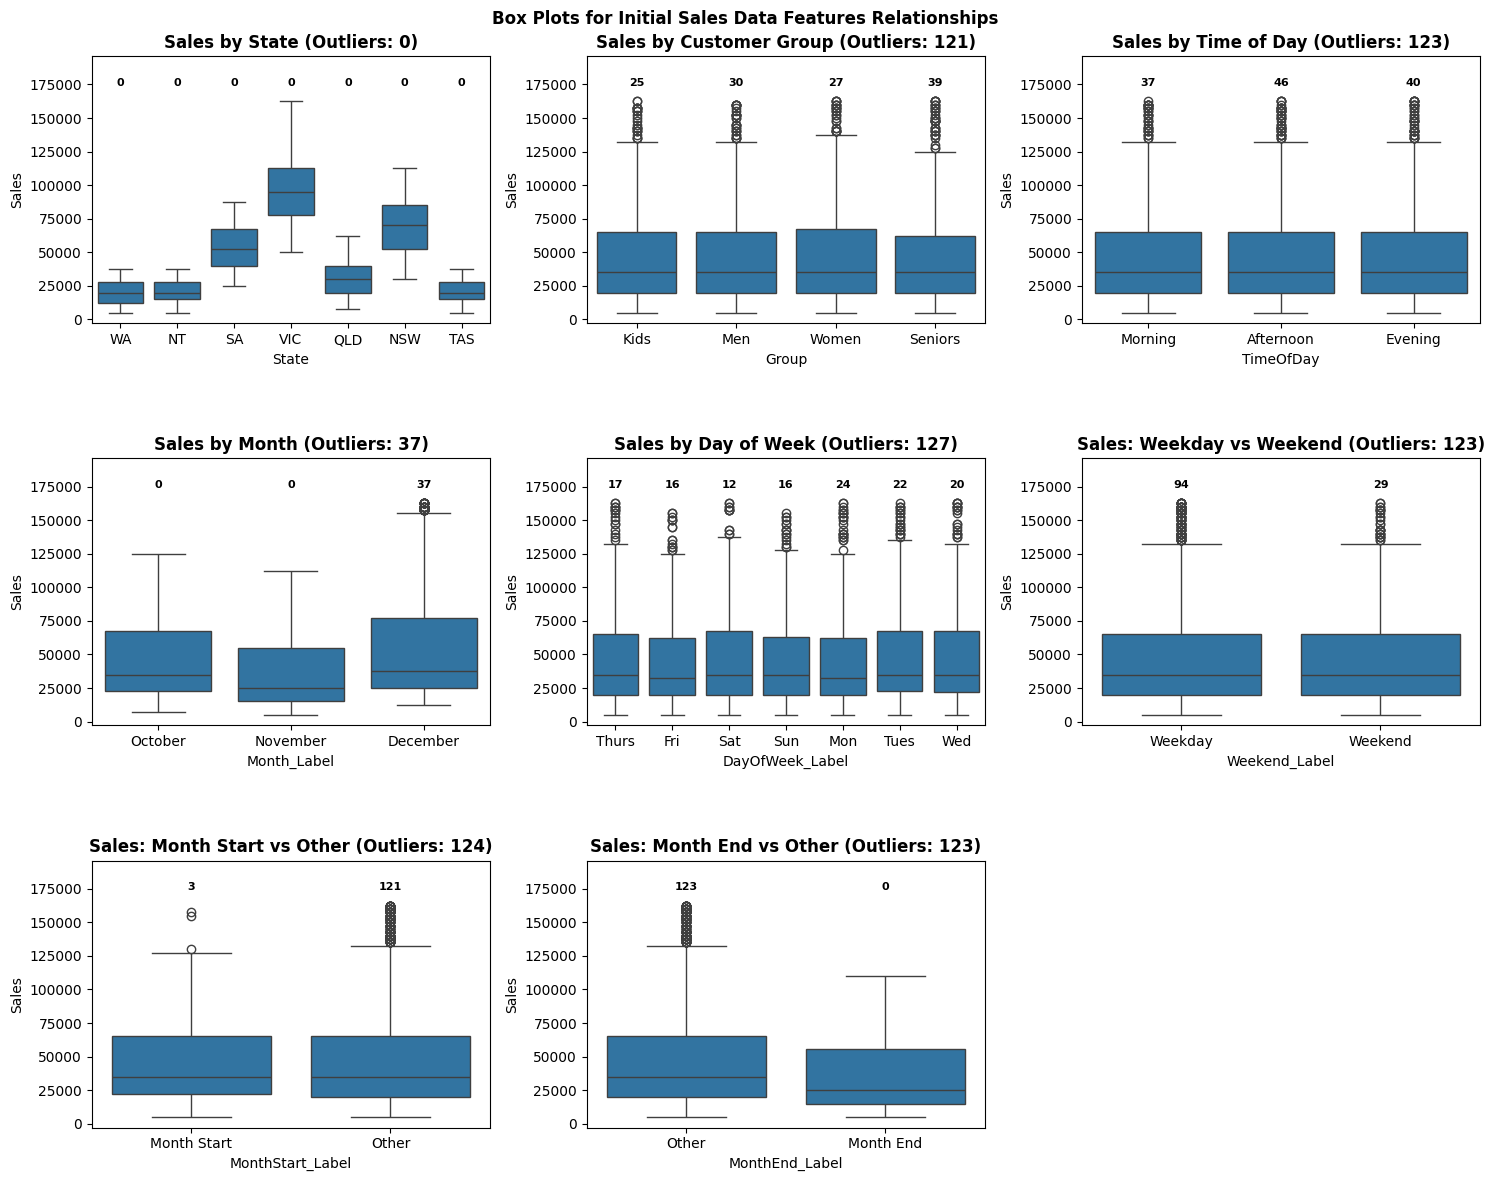

In [9]:
#
# Relational Box Plots for Sales
#

relationships_to_plot = [
    # Original categorical features
    {'XValue': 'State', 'YValue': 'Sales', 'Title': 'Sales by State'},
    {'XValue': 'Group', 'YValue': 'Sales', 'Title': 'Sales by Customer Group'},
    {'XValue': 'TimeOfDay', 'YValue': 'Sales', 'Title': 'Sales by Time of Day'},
    
    # Time-based features
    {'XValue': 'Month_Label', 'YValue': 'Sales', 'Title': 'Sales by Month'},
    {'XValue': 'DayOfWeek_Label', 'YValue': 'Sales', 'Title': 'Sales by Day of Week'},
    
    # Binary features
    {'XValue': 'Weekend_Label', 'YValue': 'Sales', 'Title': 'Sales: Weekday vs Weekend'},
    {'XValue': 'MonthStart_Label', 'YValue': 'Sales', 'Title': 'Sales: Month Start vs Other'},
    {'XValue': 'MonthEnd_Label', 'YValue': 'Sales', 'Title': 'Sales: Month End vs Other'},
]

df_ausapparalsales_with_date_features = df_ausapparalsales_new.copy(deep=True)

df_ausapparalsales_with_date_features = EncodeDateFeatures(df_ausapparalsales_with_date_features)
#PrintDataFrameStatus(df_ausapparalsales_with_date_features)
# print()

# To Make plots more readable, add labels
df_ausapparalsales_with_date_features['Month_Label'] = df_ausapparalsales_with_date_features['Month'].map({10: 'October', 11: 'November', 12: 'December' })
df_ausapparalsales_with_date_features['DayOfWeek_Label'] = df_ausapparalsales_with_date_features['DayOfWeek'].map({0: 'Mon', 1: 'Tues', 2: 'Wed', 3: 'Thurs', 4: 'Fri', 5: 'Sat', 6: 'Sun' })
df_ausapparalsales_with_date_features['Weekend_Label'] = df_ausapparalsales_with_date_features['Weekend'].map({0: 'Weekday', 1: 'Weekend'})
df_ausapparalsales_with_date_features['MonthStart_Label'] = df_ausapparalsales_with_date_features['IsMonthStart'].map({0: 'Other', 1: 'Month Start'})
df_ausapparalsales_with_date_features['MonthEnd_Label'] = df_ausapparalsales_with_date_features['IsMonthEnd'].map({0: 'Other', 1: 'Month End'})

PlotsToViewRelationships(df_ausapparalsales_with_date_features, 
                         relationships_to_plot, 
                         plot_title='Box Plots for Initial Sales Data Features Relationships',
                         plot_type='BoxPlot')

#### <b>Categorical Features versus Sales Analysis</b> ####
**Sales by State**
- VIC, NSW, SA have the highest sales overall.
  They also have the highest medians.
- WA, NT, TAS are much lower.
- No outliers.

**Sales by Customer Group**
- All groups all have similar sales ranges (total sales and medians).
- Consistent number of high-value outliers across all groups

**Sales by Time of Day**
- Similar sales across all Times of Day (overall and medians)
- Again, consistent number of high-value outliers across all Times of Day.

**Sales by Month**
- Months ranked in order of highest sales (and medians): December, October, November.
- December has most outliers — Christmas shopping?

**- Sales by Day of Week**
- Saturday is the highest, but by a small margin.
- Tues, Wed, Thurs are similar.
- For the most part the days are relatively in the same range.
- Outliers appear on every day.

**Weekday vs Weekend**
- Sales levels are about even.
- No strong preference for weekday vs weekend shopping.
- Weekend has roughly 1/3 of total outliers.

**Month Start vs Other**
- No meaningfull difference; Month Start is same as rest of month.
- Outliers in both.

**Month End vs Other**
- Month End is slightly higher (total sales/medians)
- No outliers at end of month
- Outliers spread across rest of month.

#### <b>Plots of Categorical Features versus TimeOfDay Relativity</b> ####

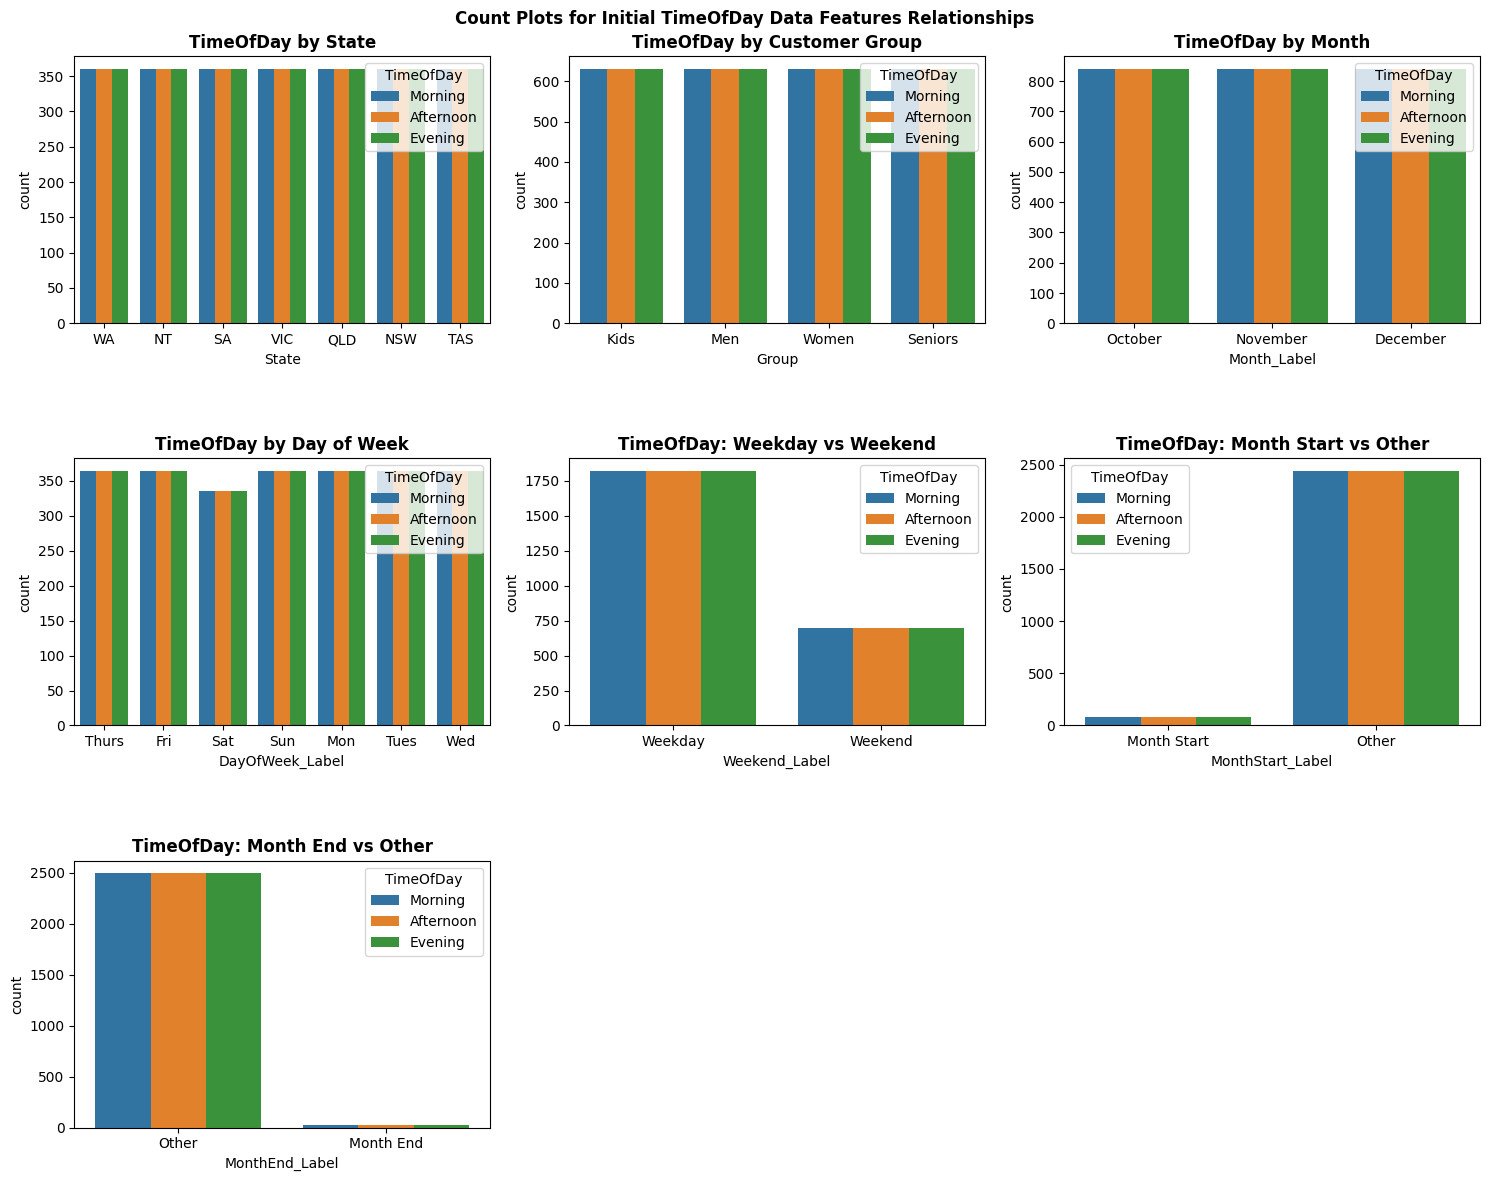

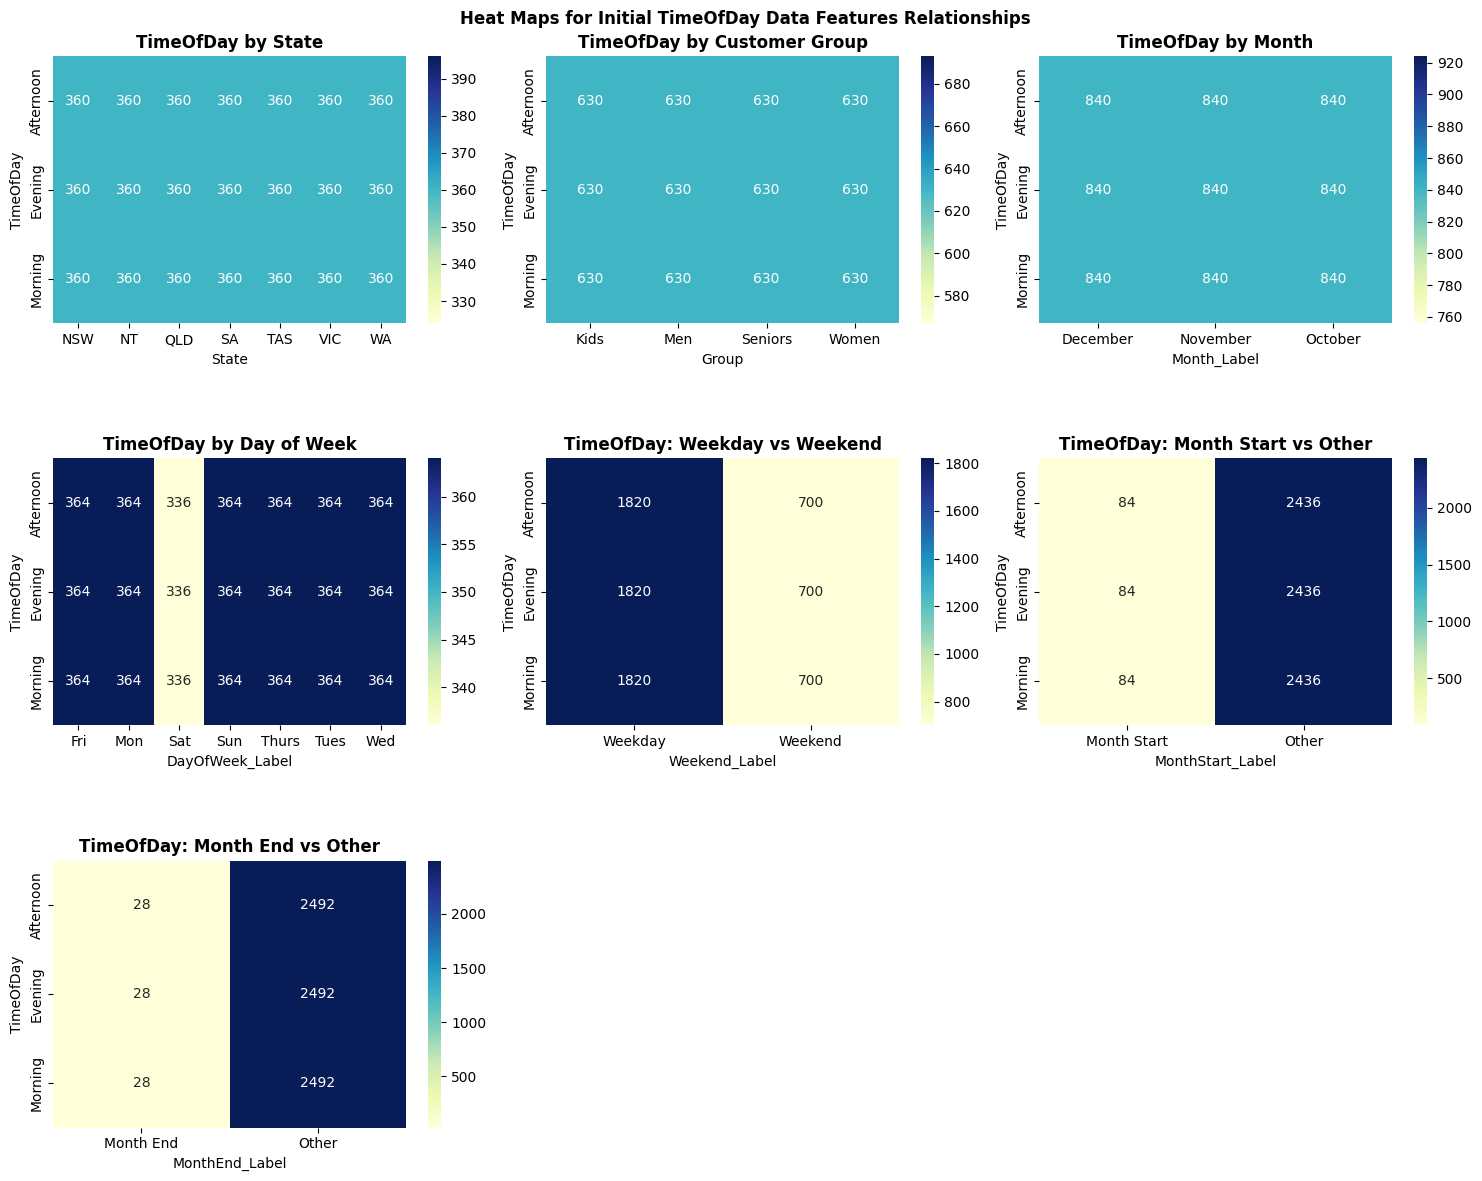

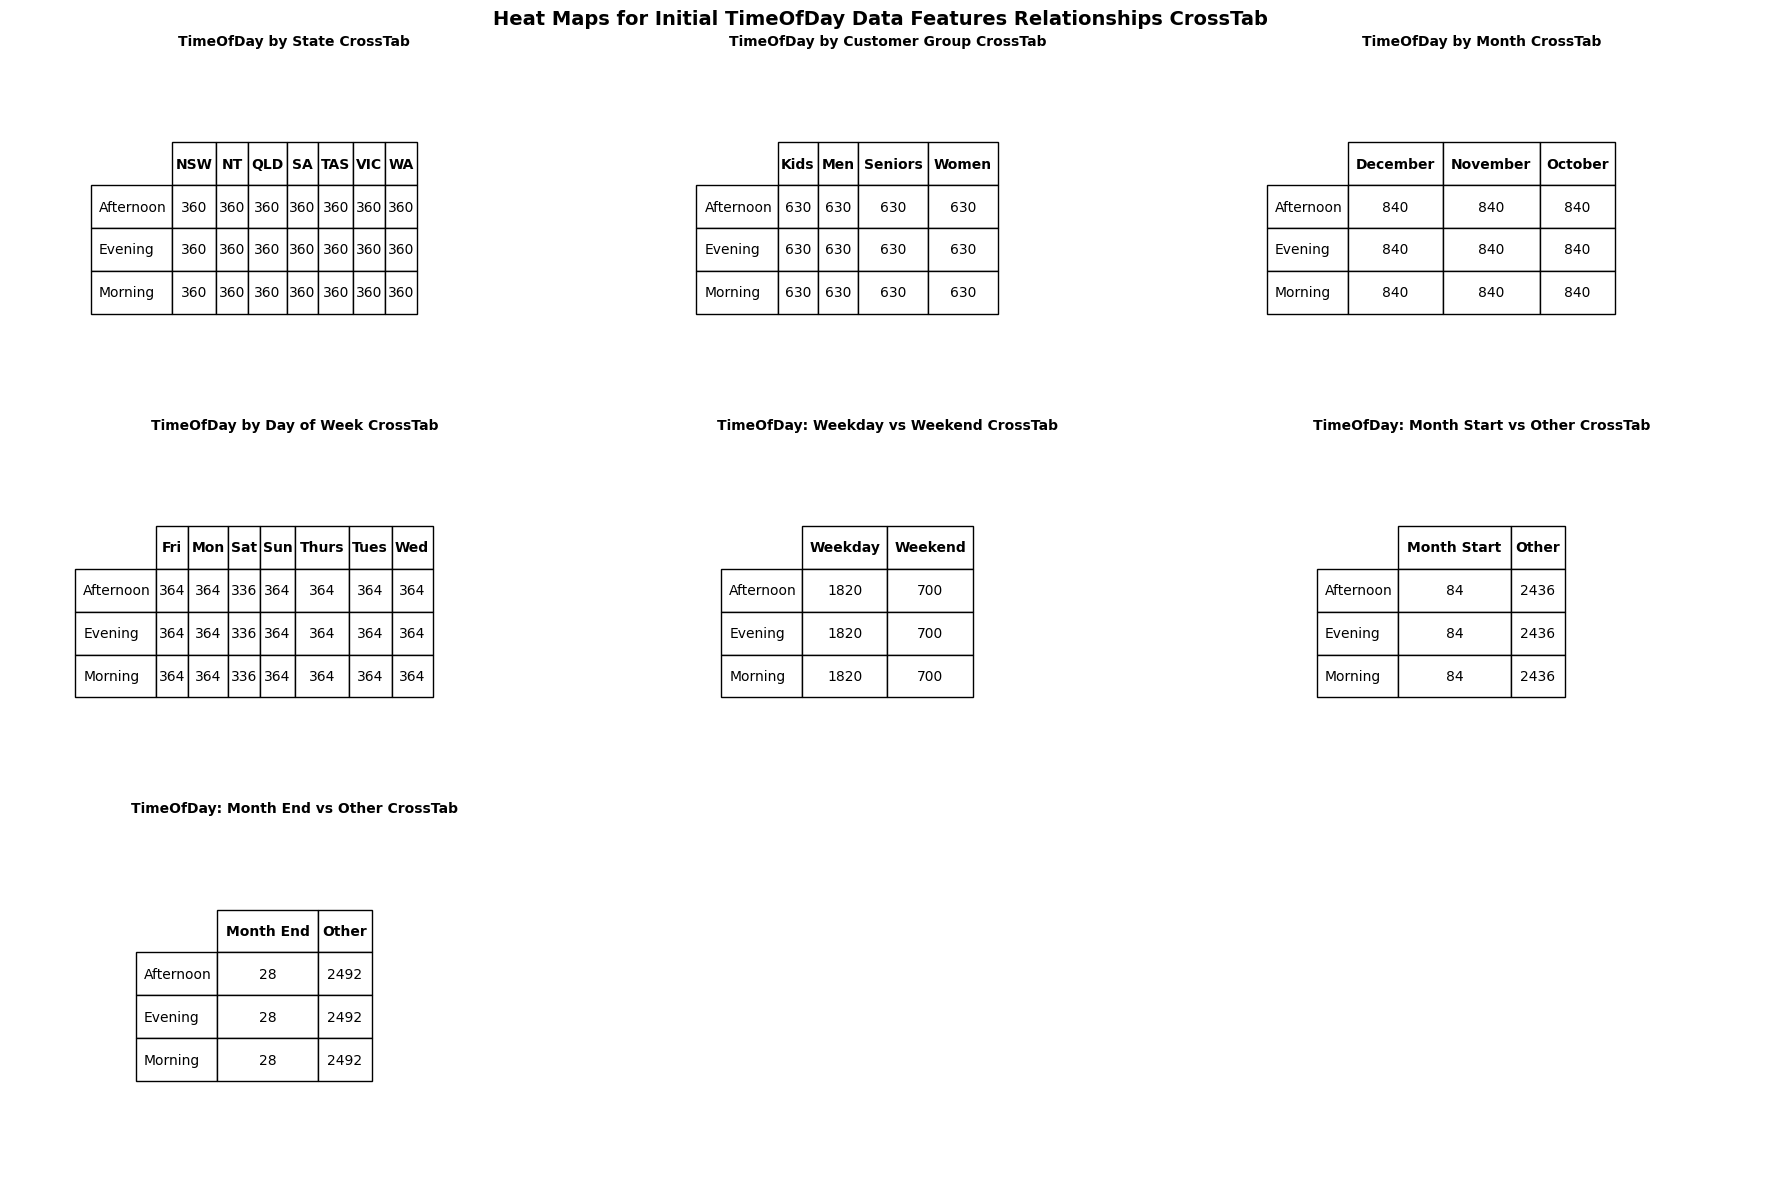

In [10]:

# Relational Box Plots for TimeOfDay
#

relationships_to_plot = [
    # Original categorical features
    {'XValue': 'State', 'YValue': 'TimeOfDay', 'Title': 'TimeOfDay by State'},
    {'XValue': 'Group', 'YValue': 'TimeOfDay', 'Title': 'TimeOfDay by Customer Group'},
    
    # Time-based features
    {'XValue': 'Month_Label', 'YValue': 'TimeOfDay', 'Title': 'TimeOfDay by Month'},
    {'XValue': 'DayOfWeek_Label', 'YValue': 'TimeOfDay', 'Title': 'TimeOfDay by Day of Week'},
    
    # Binary features
    {'XValue': 'Weekend_Label', 'YValue': 'TimeOfDay', 'Title': 'TimeOfDay: Weekday vs Weekend'},
    {'XValue': 'MonthStart_Label', 'YValue': 'TimeOfDay', 'Title': 'TimeOfDay: Month Start vs Other'},
    {'XValue': 'MonthEnd_Label', 'YValue': 'TimeOfDay', 'Title': 'TimeOfDay: Month End vs Other'},
]

PlotsToViewRelationships(df_ausapparalsales_with_date_features, 
                         relationships_to_plot, 
                         plot_title='Count Plots for Initial TimeOfDay Data Features Relationships', 
                         plot_type='CountPlot')

PlotsToViewRelationships(df_ausapparalsales_with_date_features, 
                         relationships_to_plot, 
                         plot_title='Heat Maps for Initial TimeOfDay Data Features Relationships', 
                         plot_type='HeatMap',
                         display_crosstab=True)

#### <b>Plots of Categorical Features versus TimeOfDay Analysis</b> ####
**TimeOfDay by State**
- TimeofDay is equally distributed across all States (360)
- This means your data generator or real dataset is evenly distributed by time of day regardless of state.
- Such even distribution is unusual in real world scenarios. It points to data being manufactured or somehow normalized

**TimeOfDay by Customer Group**
- TimeOfDay is equally distributed across all Groups (630)

**TimeOfDay by Month**
- TimeOfDay is equally distributed across each Month (820)

**TimeOfDay by DayofWeek**
- Counts are almost identical every day except Saturday.

**Weekday vs Weekend**
- TimeOfDay is equally distributed across Weekdays and Weekends.

**Month Start vs Other**
- TimeOfDay is equally distributed across MonthStart/Other.

**Month End vs Other**
- TimeOfDay is equally distributed across MonthEnd/Other.

**This points to a non real world dataset. (manufactured/normalized)**



#### <b>Plots of Categorical Features versus Group Relativity</b> ####

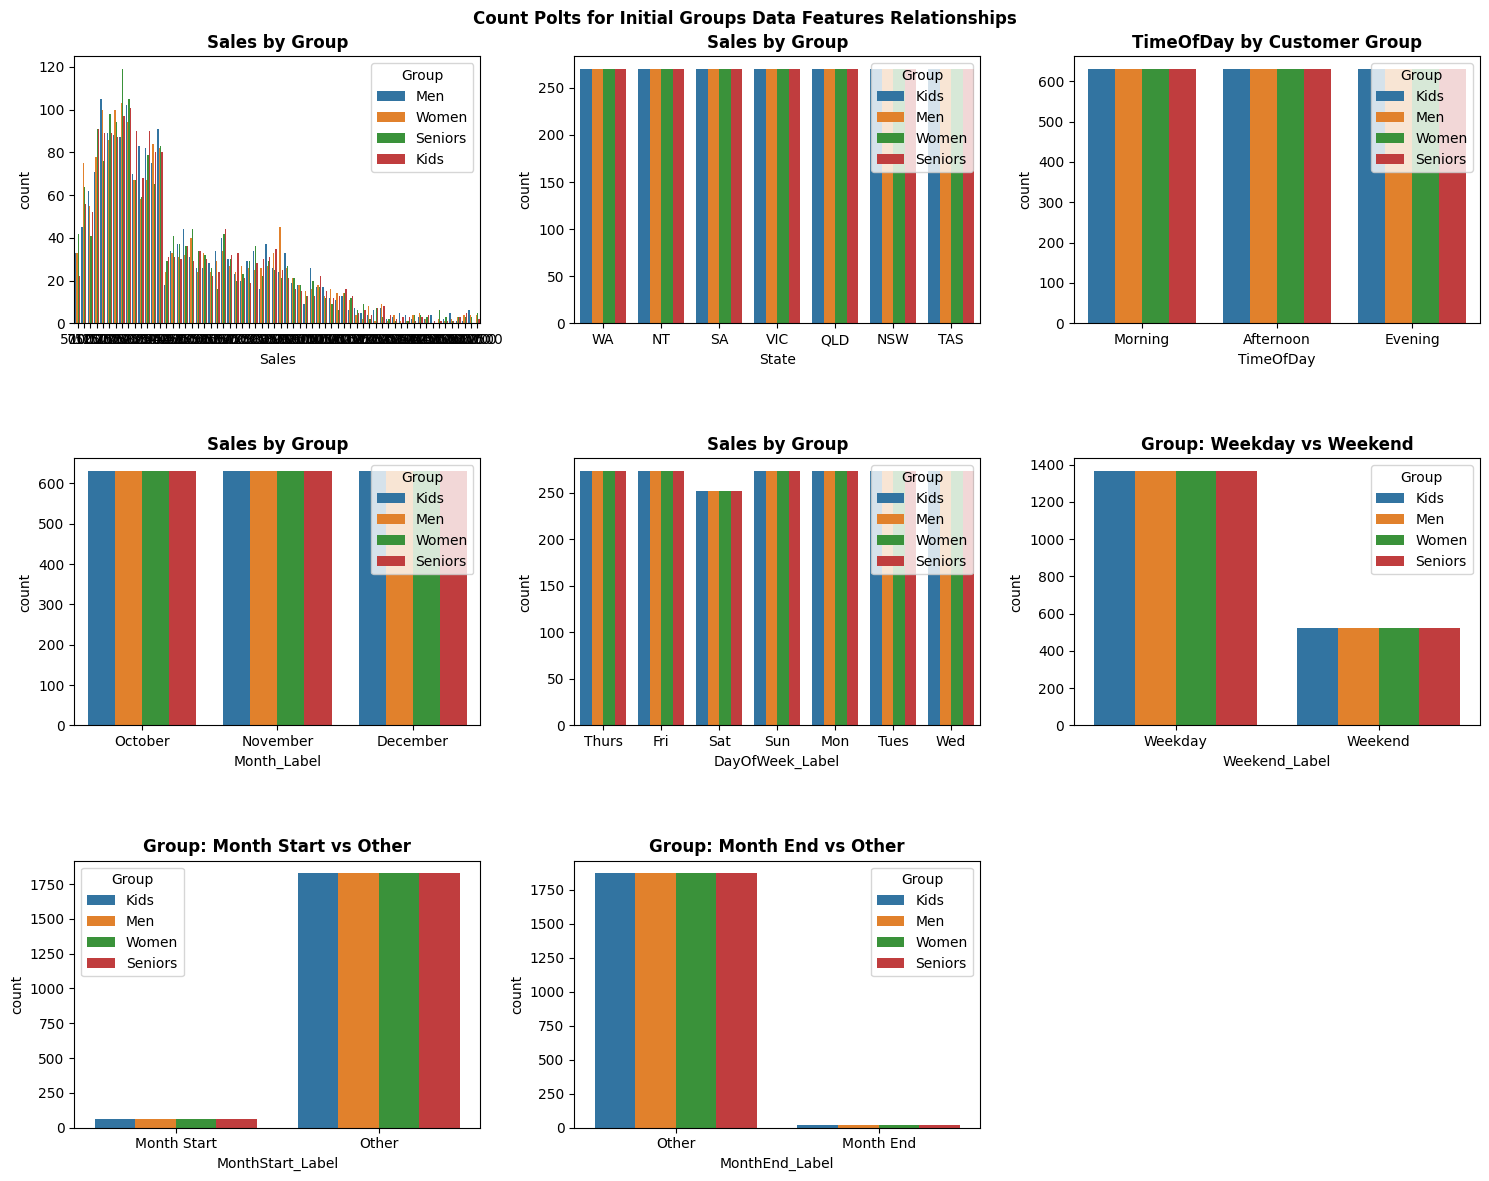

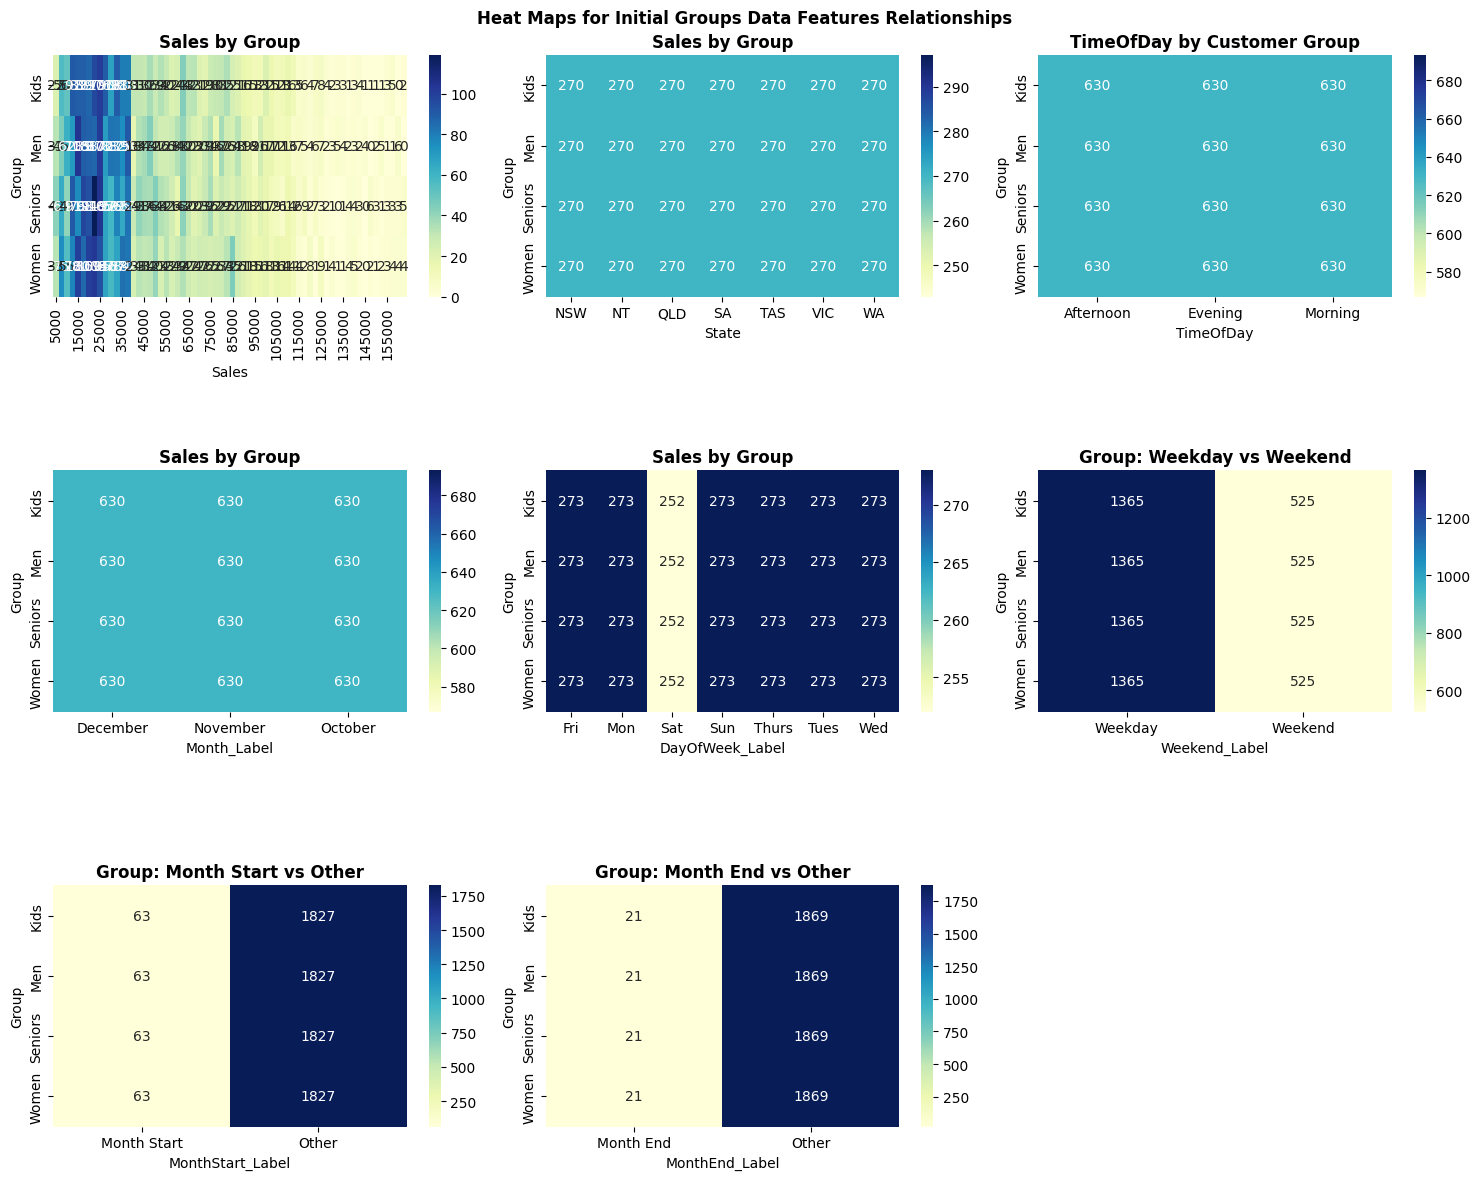

C:\Users\jxbma\AppData\Local\Temp\ipykernel_61992\2695386308.py:56: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


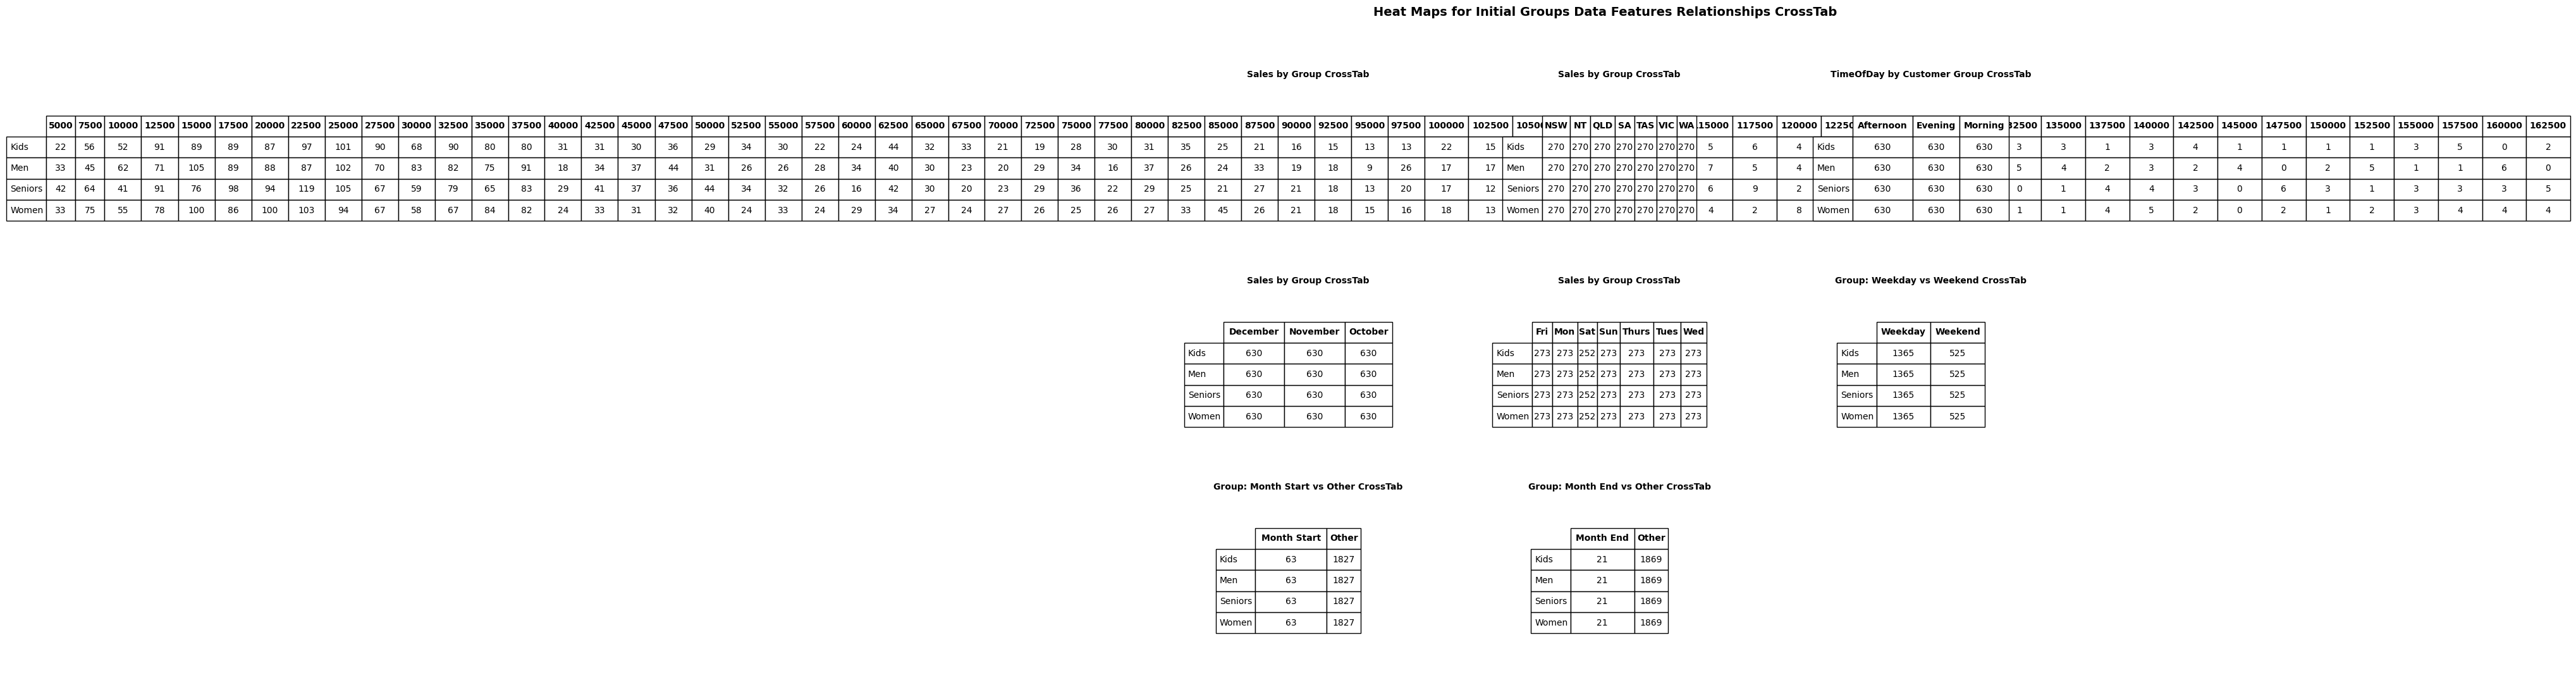

In [11]:
#PrintDataFrameStatus(df_ausapparalsales_new)
# 
# Relational Box Plots for Groups
#

relationships_to_plot = [
    # Original categorical features
    {'XValue': 'Sales', 'YValue': 'Group', 'Title': 'Sales by Group'},
    {'XValue': 'State', 'YValue': 'Group', 'Title': 'Sales by Group'},
    {'XValue': 'TimeOfDay', 'YValue': 'Group', 'Title': 'TimeOfDay by Customer Group'},
    
    # Time-based features
    {'XValue': 'Month_Label', 'YValue': 'Group', 'Title': 'Sales by Group'},
    {'XValue': 'DayOfWeek_Label', 'YValue': 'Group', 'Title': 'Sales by Group'},
    
    # Binary features
    {'XValue': 'Weekend_Label', 'YValue': 'Group', 'Title': 'Group: Weekday vs Weekend'},
    {'XValue': 'MonthStart_Label', 'YValue': 'Group', 'Title': 'Group: Month Start vs Other'},
    {'XValue': 'MonthEnd_Label', 'YValue': 'Group', 'Title': 'Group: Month End vs Other'},
]

PlotsToViewRelationships(df_ausapparalsales_with_date_features, 
                         relationships_to_plot, 
                         plot_title='Count Polts for Initial Groups Data Features Relationships', 
                         plot_type='CountPlot')

PlotsToViewRelationships(df_ausapparalsales_with_date_features, 
                         relationships_to_plot, 
                         plot_title='Heat Maps for Initial Groups Data Features Relationships', 
                         plot_type='HeatMap',
                         display_crosstab=True)

#### <b>Plots of Categorical Features versus Group Analysis</b> ####
**Sales by Group**
- Plot shows some differences in data.
- All 4 groups (Kids, Men, Women, Seniors) exhibit the pattern across Sales.
  Seniors are higest, followed by Women, Men and then Kids
- It's hard to read the plot. We can get more clarity by binning the data and replotting.
    - **Task:** Bin and Replot

**All Other**
- Group seems to be equally balanced across all the remaining features.

#### <b>Plots of Categorical Features versus State Relativity</b> ####

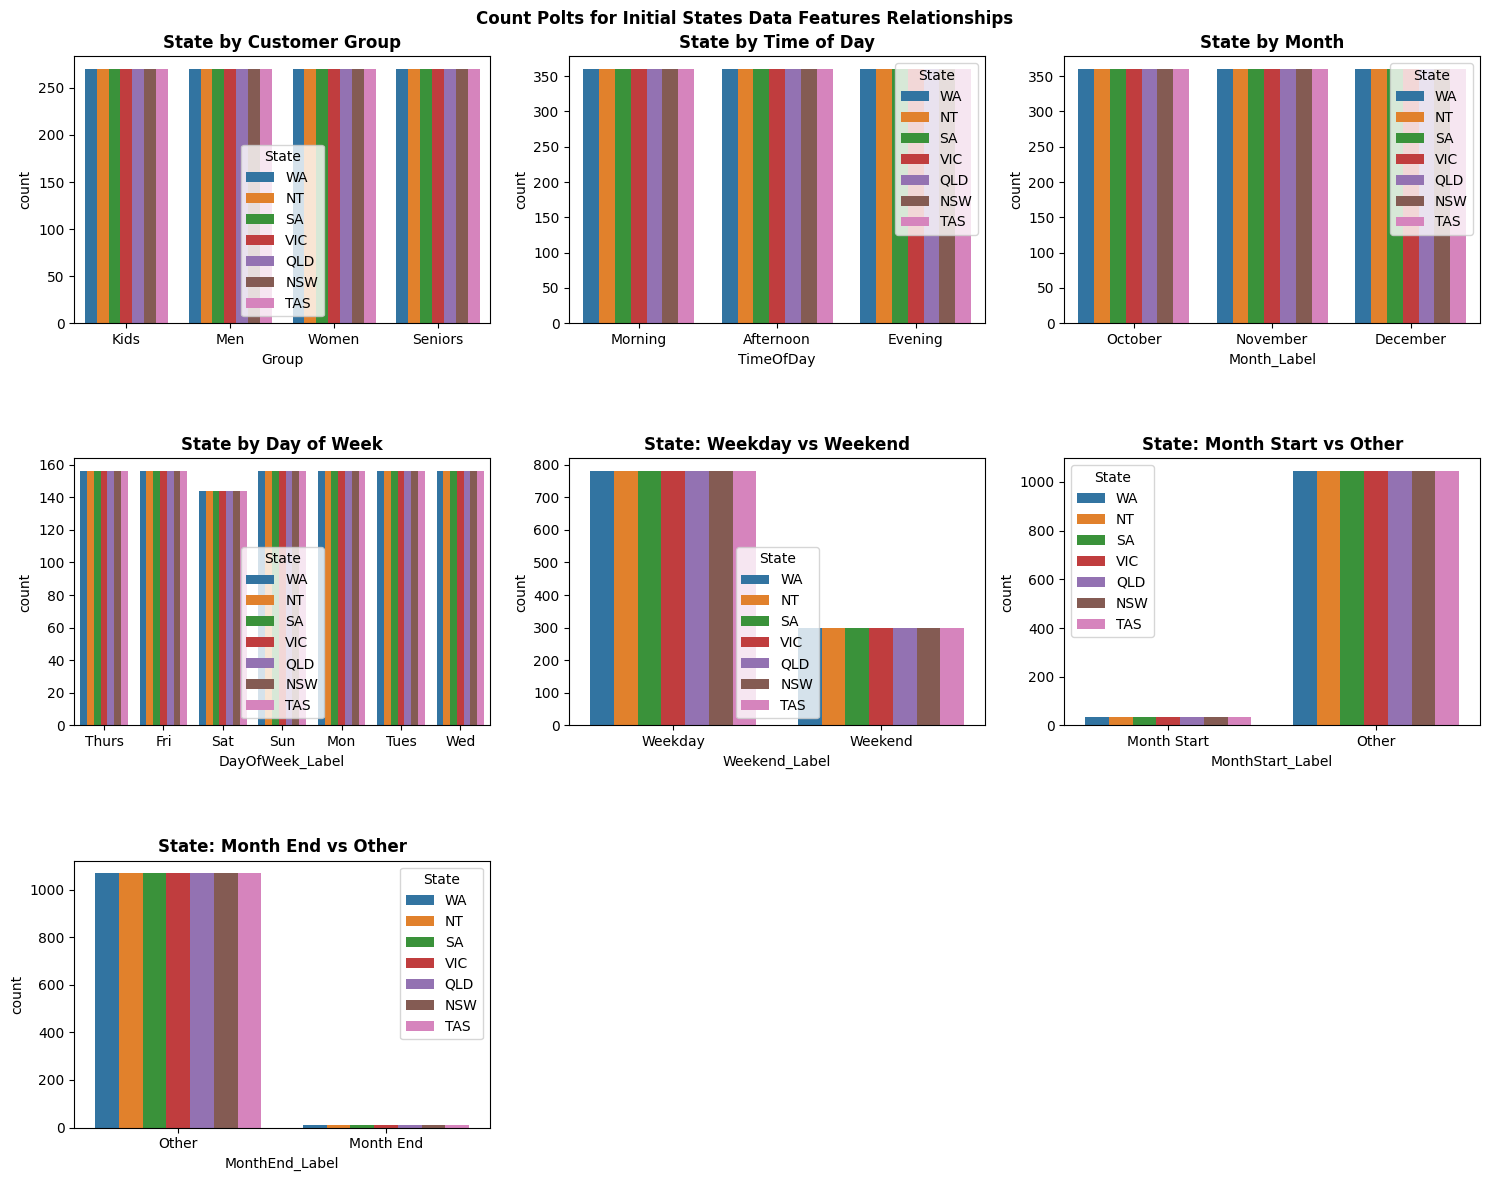

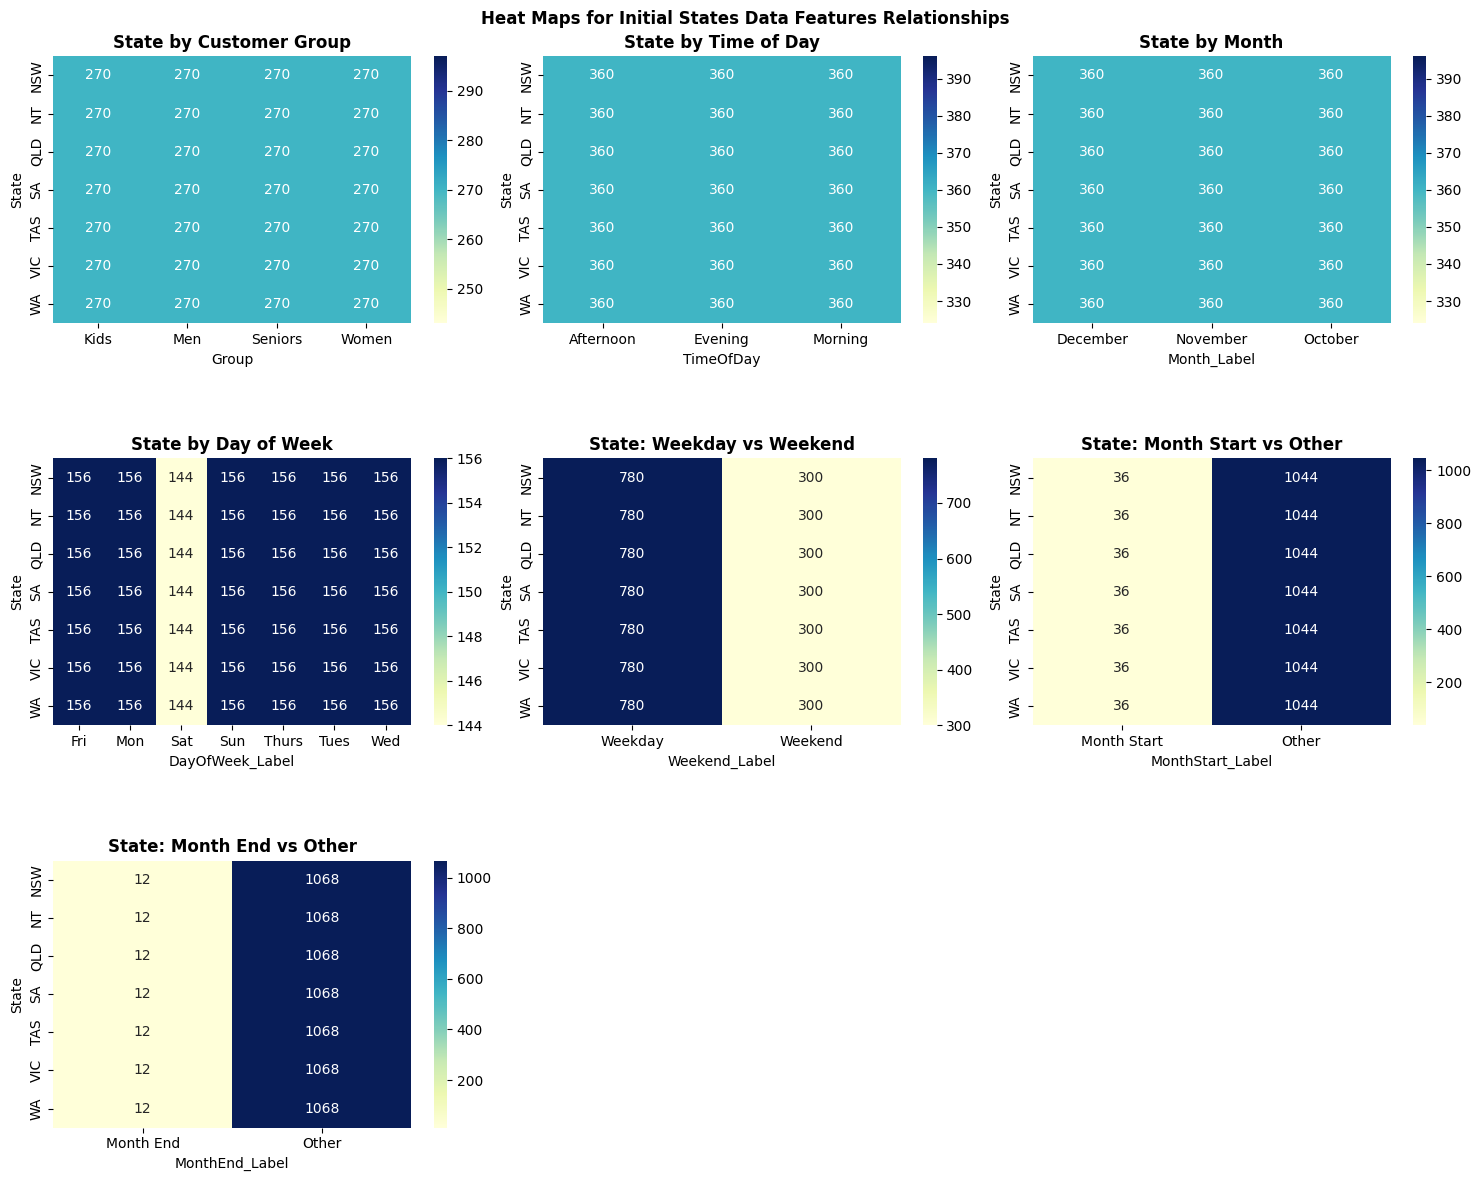

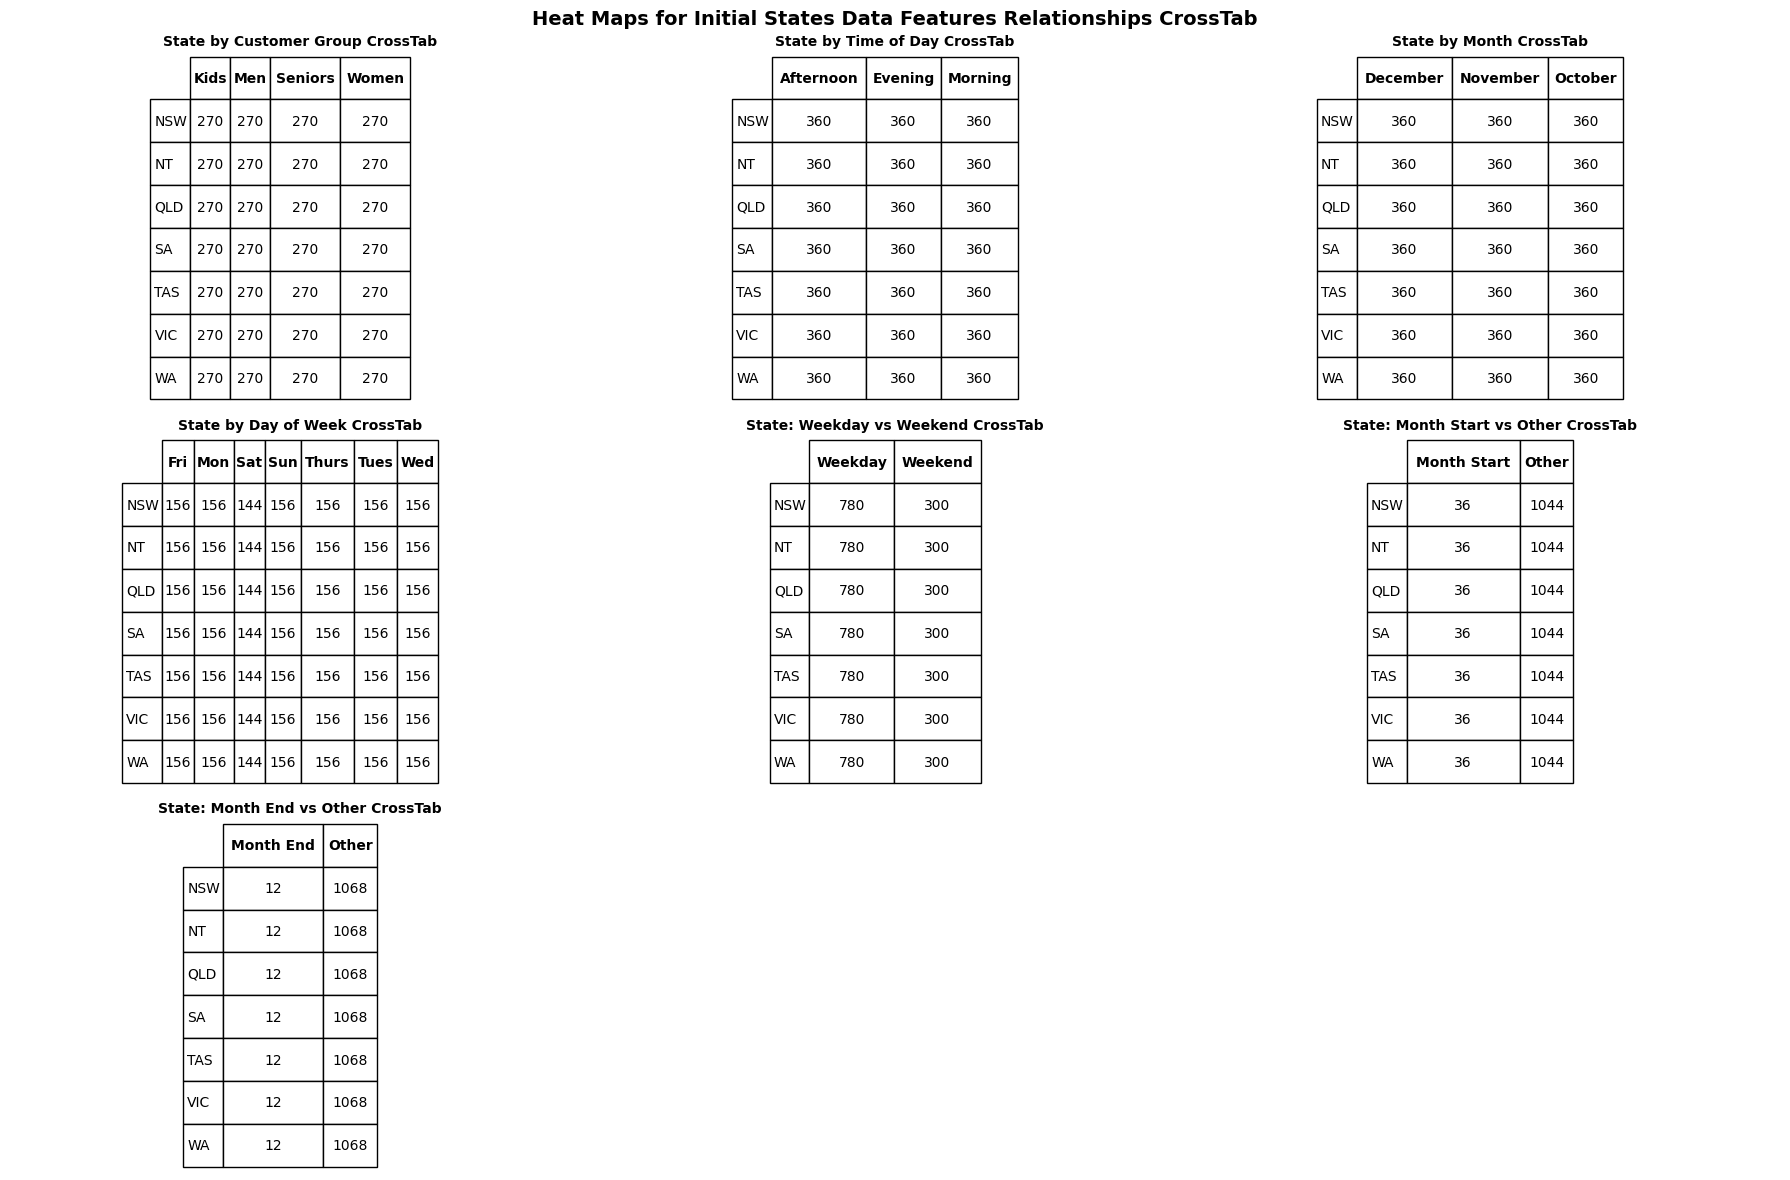

In [12]:
#
# Relational Box Plots for States
#

relationships_to_plot = [
    # Original categorical features
    {'XValue': 'Group', 'YValue': 'State', 'Title': 'State by Customer Group'},
    {'XValue': 'TimeOfDay', 'YValue': 'State', 'Title': 'State by Time of Day'},
    
    # Time-based features
    {'XValue': 'Month_Label', 'YValue': 'State', 'Title': 'State by Month'},
    {'XValue': 'DayOfWeek_Label', 'YValue': 'State', 'Title': 'State by Day of Week'},
    
    # Binary features
    {'XValue': 'Weekend_Label', 'YValue': 'State', 'Title': 'State: Weekday vs Weekend'},
    {'XValue': 'MonthStart_Label', 'YValue': 'State', 'Title': 'State: Month Start vs Other'},
    {'XValue': 'MonthEnd_Label', 'YValue': 'State', 'Title': 'State: Month End vs Other'},
]

PlotsToViewRelationships(df_ausapparalsales_with_date_features, 
                         relationships_to_plot, 
                         plot_title='Count Polts for Initial States Data Features Relationships', 
                         plot_type='CountPlot')

PlotsToViewRelationships(df_ausapparalsales_with_date_features, 
                         relationships_to_plot, 
                         plot_title='Heat Maps for Initial States Data Features Relationships', 
                         plot_type='HeatMap',
                         display_crosstab=True)

#### <b>Plots of Categorical Features versus State Analysis</b> ####
**State across all other categorical features.**
- We don't really learn anything from these plots which we've seen from most of the others. The data perfectly evenly distributed across all categories
- This is highly indicative of a carefully manufactured dataset.
- The **only interesting relationship** that is worth exploring is **Sales across Groups**.

### **Encode the Categorical Features** ###    

In [13]:
#
# Call Encoder function
#
df_ausapparalsales_new = EncodeCategoricalFeatures(df_ausapparalsales_new)
#PrintDataFrameStatus(df_ausapparalsales_new)

Ordinal encoding mapping:


#### <b>Data Type Conversion</b> ####
    The next step is to convert data types into optimal performance types
        Unit                int64          ==> int8
        Sales               int64          ==> int32
        Month               int32          ==> int8
        DayOfWeek           int32          ==> int8
        Day                 int32          ==> int16
        WeekOfYear          UInt32         ==> int8
        Weekend             int64          ==> int8
        State_NT            float64        ==> int8
        State_QLD           float64        ==> int8
        State_SA            float64        ==> int8
        State_TAS           float64        ==> int8
        State_VIC           float64        ==> int8
        State_WA            float64        ==> int8
        Group_Men           float64        ==> int8
        Group_Seniors       float64        ==> int8
        Group_Women         float64        ==> int8
        TimeOfDay_encoded   float64        ==> int8 


In [14]:
# Data Type Conversions

# int8 Conversions
columns = ['Unit','Month','DayOfWeek','WeekOfYear','Weekend','State_NT',
            'State_QLD','State_SA','State_TAS','State_VIC','State_WA',
            'Group_Men','Group_Seniors','Group_Women','TimeOfDay_encoded']
df_ausapparalsales_new[columns] = df_ausapparalsales_new[columns].astype('int8')

# int32 Conversions
columns = ['Sales']
df_ausapparalsales_new[columns] = df_ausapparalsales_new[columns].astype('int32')
#PrintDataFrameStatus(df_ausapparalsales_new)

#### <b>Normalize Previously Identified Skewed Distributions - Sales and Unit</b> ####
    Identify best normalization method for Sales and Unit by trying StandardScaler(), log, Box-Cox and Yeo-Johnson.
    Plot the results and compare to decide on best normalzation routine for each feature.

##### **Compare Normalization Techniques** #####

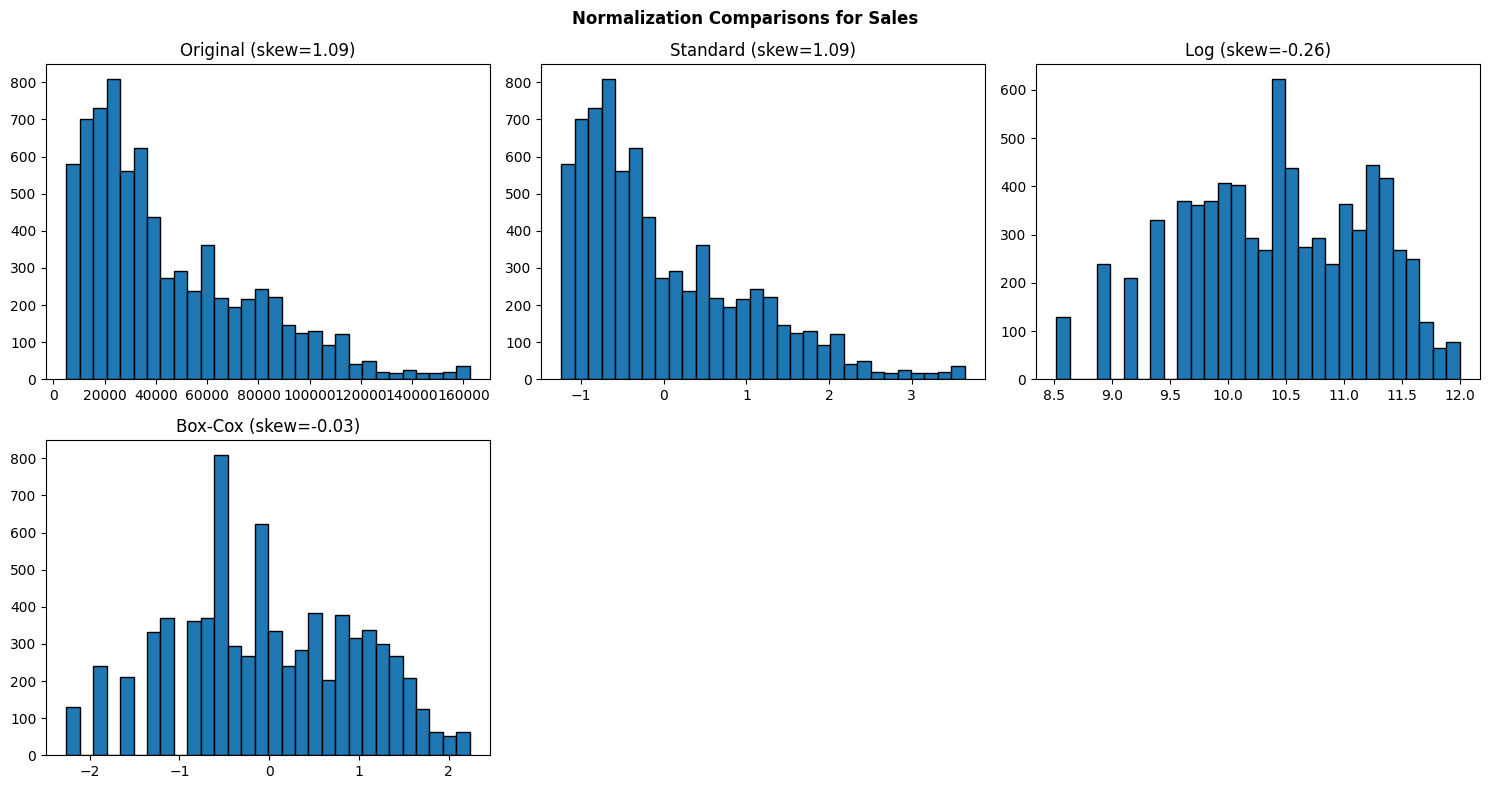

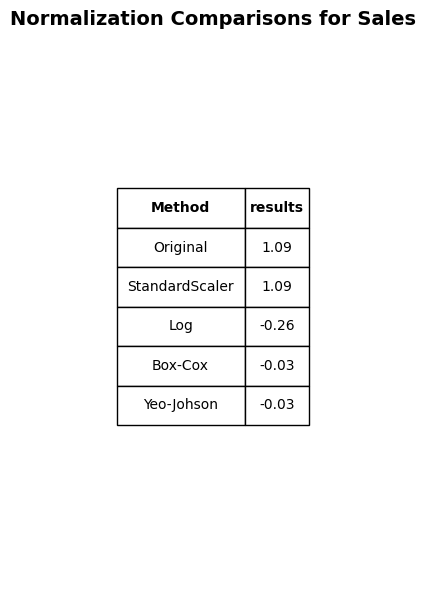

c:\Users\jxbma\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1272: RuntimeWarning: overflow encountered in scalar multiply
  result = (count * (count - 1) ** 0.5 / (count - 2)) * (m3 / m2**1.5)


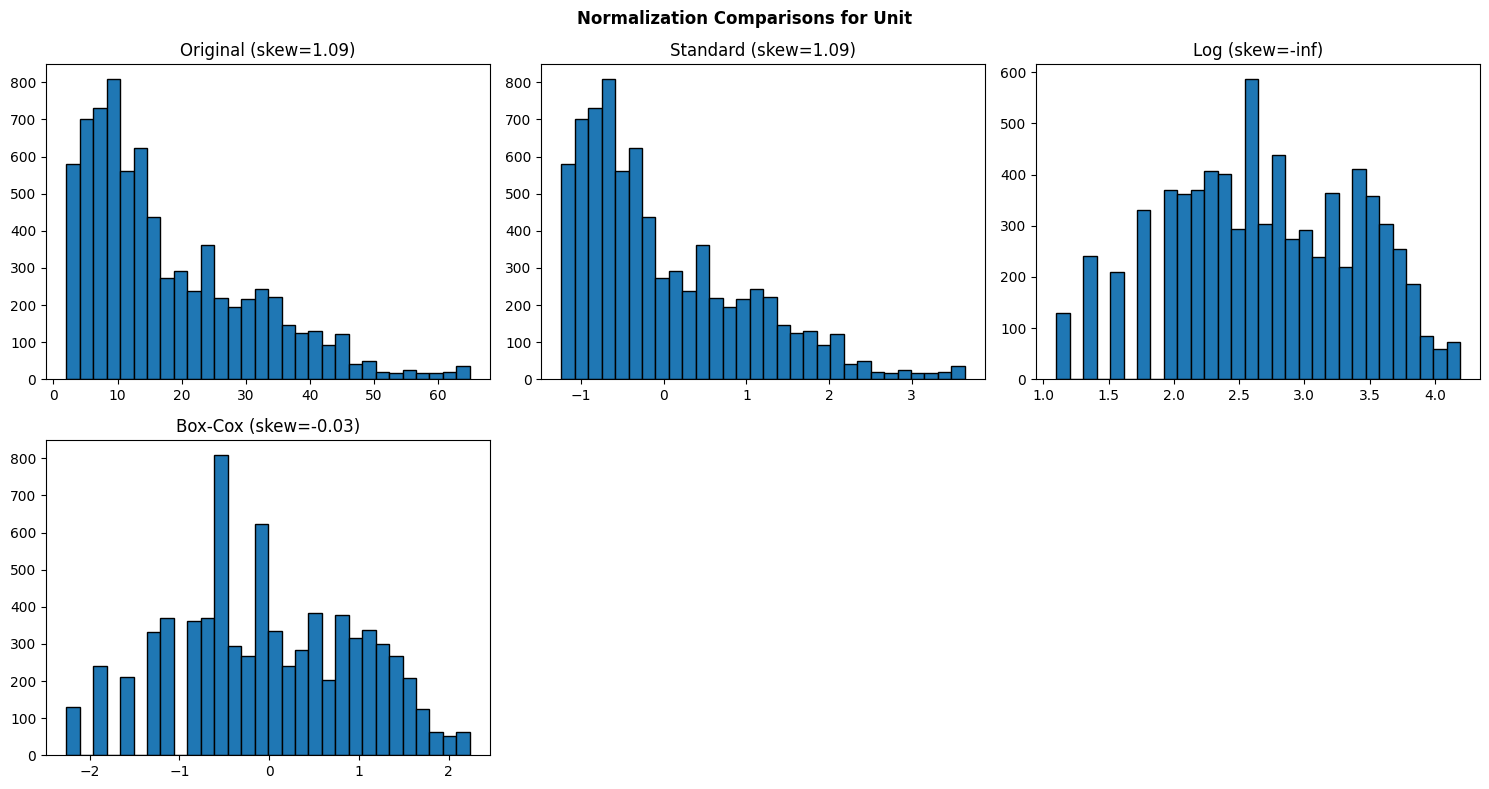

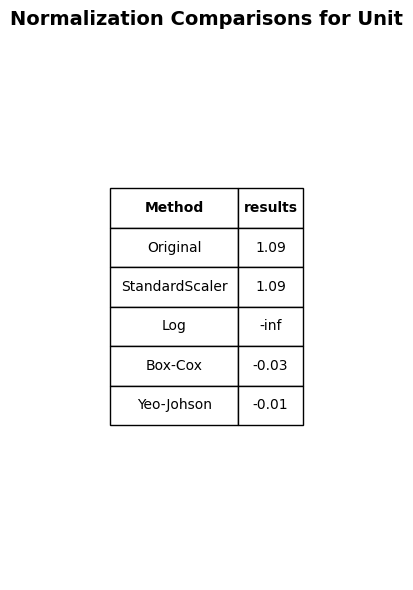

In [15]:
def CompareNormalizationMethods(df_target, feature_name):

    normalization_results = []

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()  # Now axes has 6 elements

    # Original
    axes[0].hist(df_target[feature_name], bins=30, edgecolor='black')
    axes[0].set_title(f"Original (skew={df_target[feature_name].skew():.2f})")
    normalization_results.append({'Method':'Original', 'results': f'{df_target[feature_name].skew():.2f}'})

    # Standard
    scaler = StandardScaler()
    scaled = scaler.fit_transform(df_target[[feature_name]]).flatten()
    axes[1].hist(scaled, bins=30, edgecolor='black')
    axes[1].set_title(f"Standard (skew={pd.Series(scaled).skew():.2f})")
    normalization_results.append({'Method':'StandardScaler', 'results': f'{pd.Series(scaled).skew():.2f}'})

    # Log
    log_vals = np.log1p(df_target[feature_name])
    axes[2].hist(log_vals, bins=30, edgecolor='black')
    axes[2].set_title(f"Log (skew={log_vals.skew():.2f})")
    normalization_results.append({'Method':'Log', 'results': f'{log_vals.skew():.2f}'})

    plot_count = 3  # track how many plots used

    # Box-Cox
    if df_target[feature_name].min() > 0:
        scaler = PowerTransformer(method='box-cox')
        scaled = scaler.fit_transform(df_target[[feature_name]]).flatten()
        axes[plot_count].hist(scaled, bins=30, edgecolor='black')
        axes[plot_count].set_title(f"Box-Cox (skew={pd.Series(scaled).skew():.2f})")
        normalization_results.append({'Method':'Box-Cox', 'results': f'{pd.Series(scaled).skew():.2f}'})
        plot_count += 1

    # Yeo-Johnson
    scaler = PowerTransformer(method='yeo-johnson')
    scaled = scaler.fit_transform(df_target[[feature_name]]).flatten()
    axes[plot_count].hist(scaled, bins=30, edgecolor='black')
    axes[plot_count].set_title(f"Yeo-Johnson (skew={pd.Series(scaled).skew():.2f})")
    normalization_results.append({'Method':'Yeo-Johson', 'results': f'{pd.Series(scaled).skew():.2f}'})

    # Hide unused plots
    for i in range(plot_count, len(axes)):
        fig.delaxes(axes[i])

    plt.suptitle(f'Normalization Comparisons for {feature_name}', fontweight='bold')
    plt.tight_layout()
    plt.show()
    print()
    print()

    df_results = pd.DataFrame(normalization_results)
    DisplayTable(df_results, f'Normalization Comparisons for {feature_name}')


#PrintDataFrameStatus(df_ausapparalsales_new)

skewed_features = ['Sales', 'Unit']    
for feature in skewed_features:
    CompareNormalizationMethods(df_ausapparalsales_new, feature)

##### **Compare Normalization Techniques** #####
For both Scale and Unit features, Yeo-Johnson is the best normlization technique with the lowest skewness score
- Sales => -0.29 
- Unit  => -0.01

##### **Apply Yeo-Johnson** #####

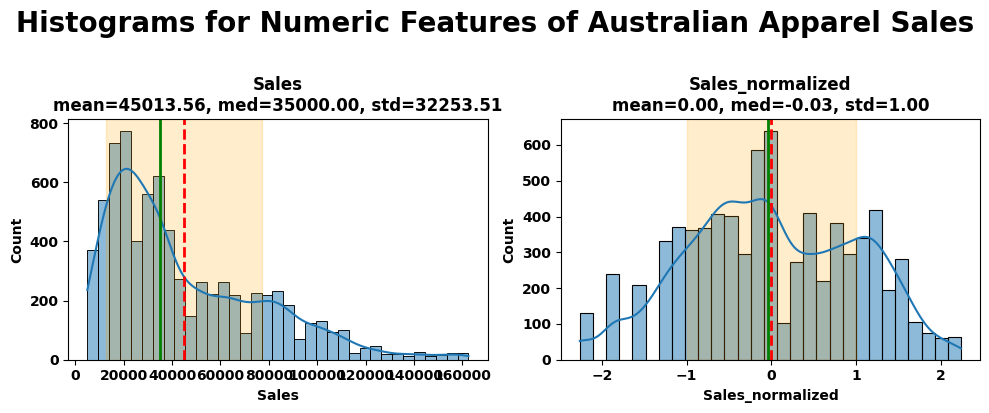

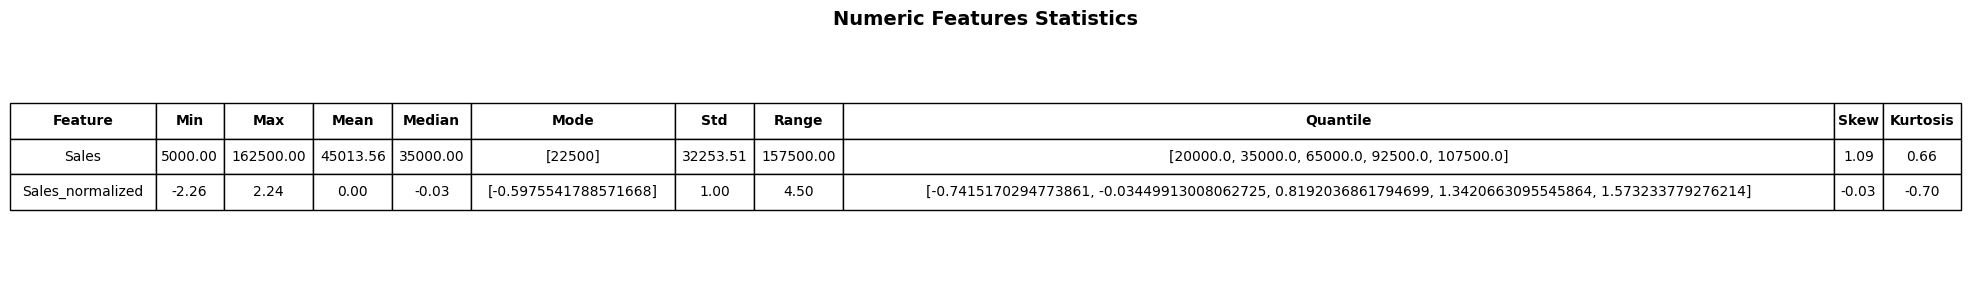

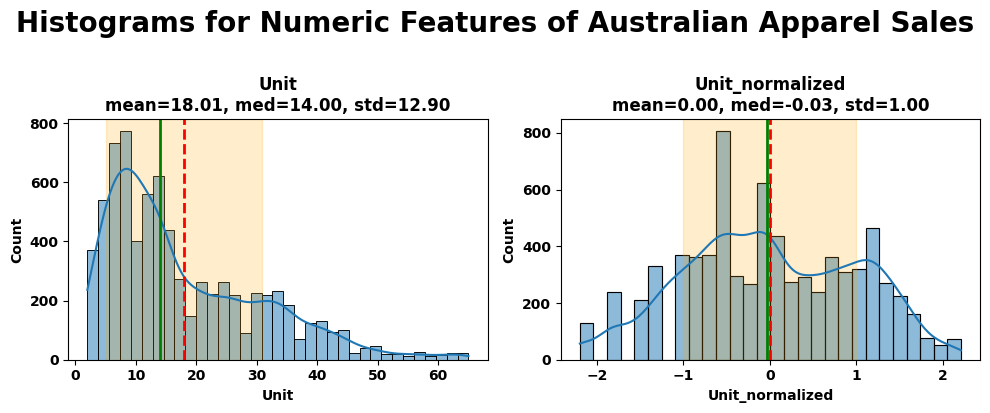

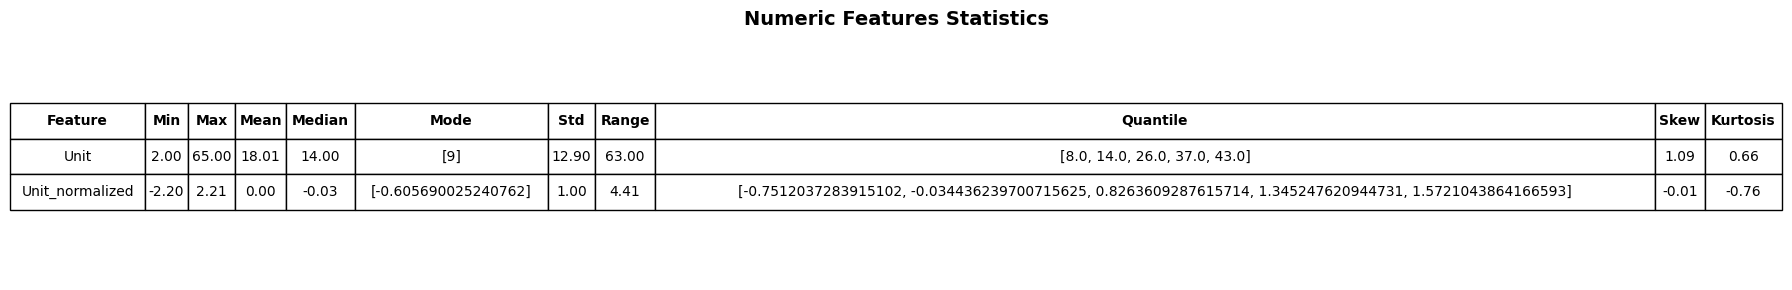

In [16]:
#
# Apply Normalization
#

#PrintDataFrameStatus(df_ausapparalsales_new)

scaler = PowerTransformer(method='yeo-johnson')
df_ausapparalsales_new['Sales_normalized'] = scaler.fit_transform(df_ausapparalsales_new[['Sales']])
df_ausapparalsales_new['Unit_normalized'] = scaler.fit_transform(df_ausapparalsales_new[['Unit']])

skewed_features=['Sales', 'Sales_normalized']
DisplayNumericFeatureHistgorams(df_ausapparalsales_new, 
                                feature_columns=skewed_features, 
                                plot_title='Normalized Distributions for Sales')

skewed_features=['Unit', 'Unit_normalized']
DisplayNumericFeatureHistgorams(df_ausapparalsales_new, 
                                feature_columns=skewed_features, 
                                plot_title='Normalized Distributions for Unit')

##### **Analysis Yeo-Johnson Normalization Results** #####
Both Sales and Unit have more normalized distributions - the right skewdness had been removed.
- Mean and Median appear equal centering the Standard Deviation.
- The both have what looks like they are bimodal distributions with second lower peaks occuring on the positive side of the mean.

##### **Add Binning to Sales** #####
It was noted earlier when comparing Sales and Categoric Features that the model when benefit from binning sales.
- Apply the binning and display the results in a plot

C:\Users\jxbma\AppData\Local\Temp\ipykernel_61992\2127042340.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_binned_sales, x='Sales_binned',


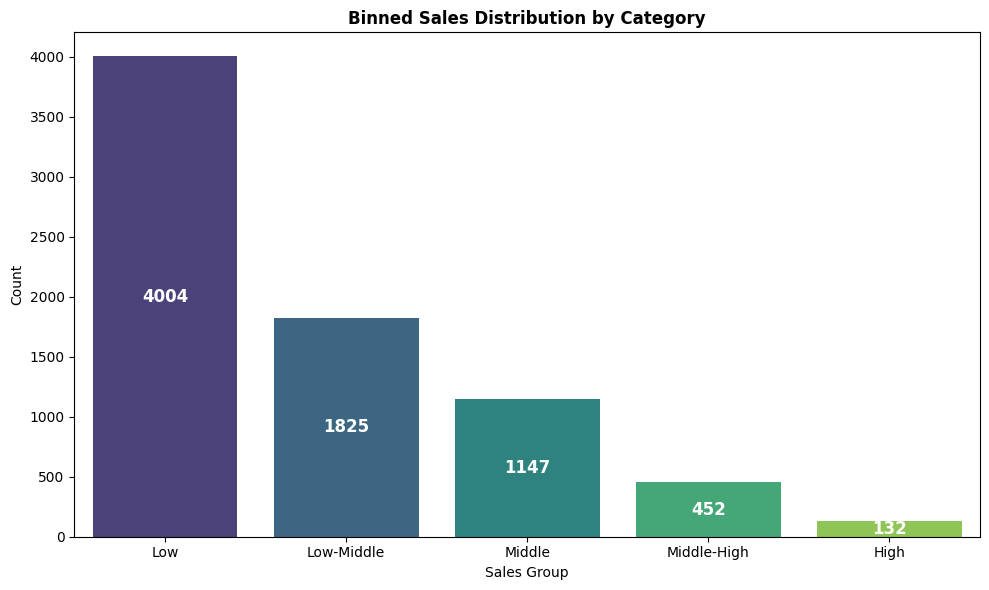

In [17]:
#
# Bin Sales
#

# Create temporary dataframe
df_binned_sales = df_ausapparalsales_new.copy()

# Bin income into 5 categories
df_binned_sales['Sales_binned'] = pd.cut(
                                            df_binned_sales['Sales'],
                                            bins=5,
                                            labels=['Low', 'Low-Middle', 'Middle', 'Middle-High', 'High']
                                        )

# Check the distribution
#print(df_binned_sales['Sales_binned'].value_counts())

# Plot countplot
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df_binned_sales, x='Sales_binned', 
                  order=['Low', 'Low-Middle', 'Middle', 'Middle-High', 'High'],
                  palette='viridis')

for container in ax.containers:
    ax.bar_label(container, label_type='center', color='white', fontweight='bold', fontsize=12)

plt.title('Binned Sales Distribution by Category', fontweight='bold')
plt.xlabel('Sales Group')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
print()
print()

df_ausapparalsales_new['Sales_binned'] = pd.cut(
                                            df_binned_sales['Sales'],
                                            bins=5,
                                            labels=['Low', 'Low-Middle', 'Middle', 'Middle-High', 'High']
                                        )

#### **GroupBy() for Data Chunking And Merging** ####
- Definitions
    - **Chunking** - Splitting of data into groups, to be analyzed separately
    - **Examples** 
        - We will chunk by State and Group
    - **Merging** - Calculating group stats, to be added back to original data (potentially useful for models)

- For our purposes, **Chunking** will be useful in getting a better understanding of relationships and trends in our data set.
- If we were to continue to the Model building phase, we would look at employing **Merging** to add features to our data set.
- For demo purposes here, we will applying some **Merging** techniques and examine them without merging the back into our ongoing dataset.
- For purposes of this demo, we will revert back to a copy of our original data set (with date transformations applied).
##### **Examination of GroupBy() for Data Chunking** #####

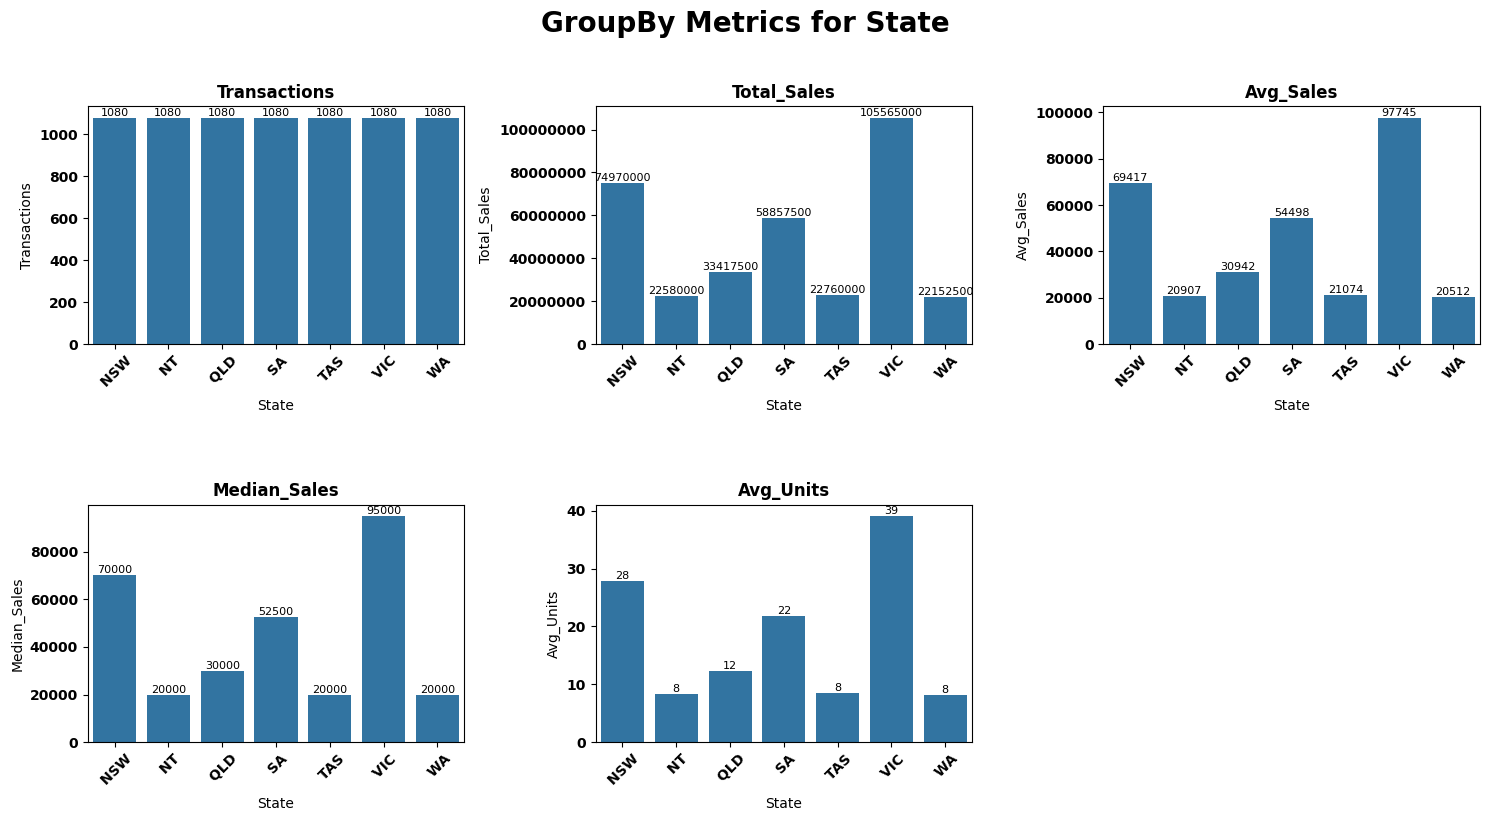

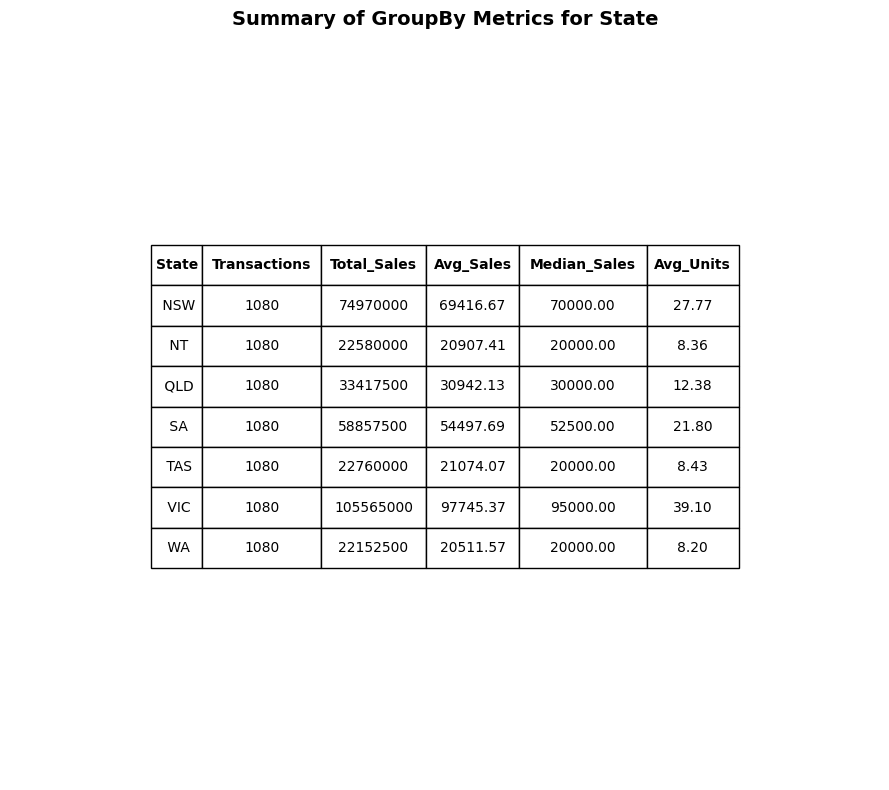

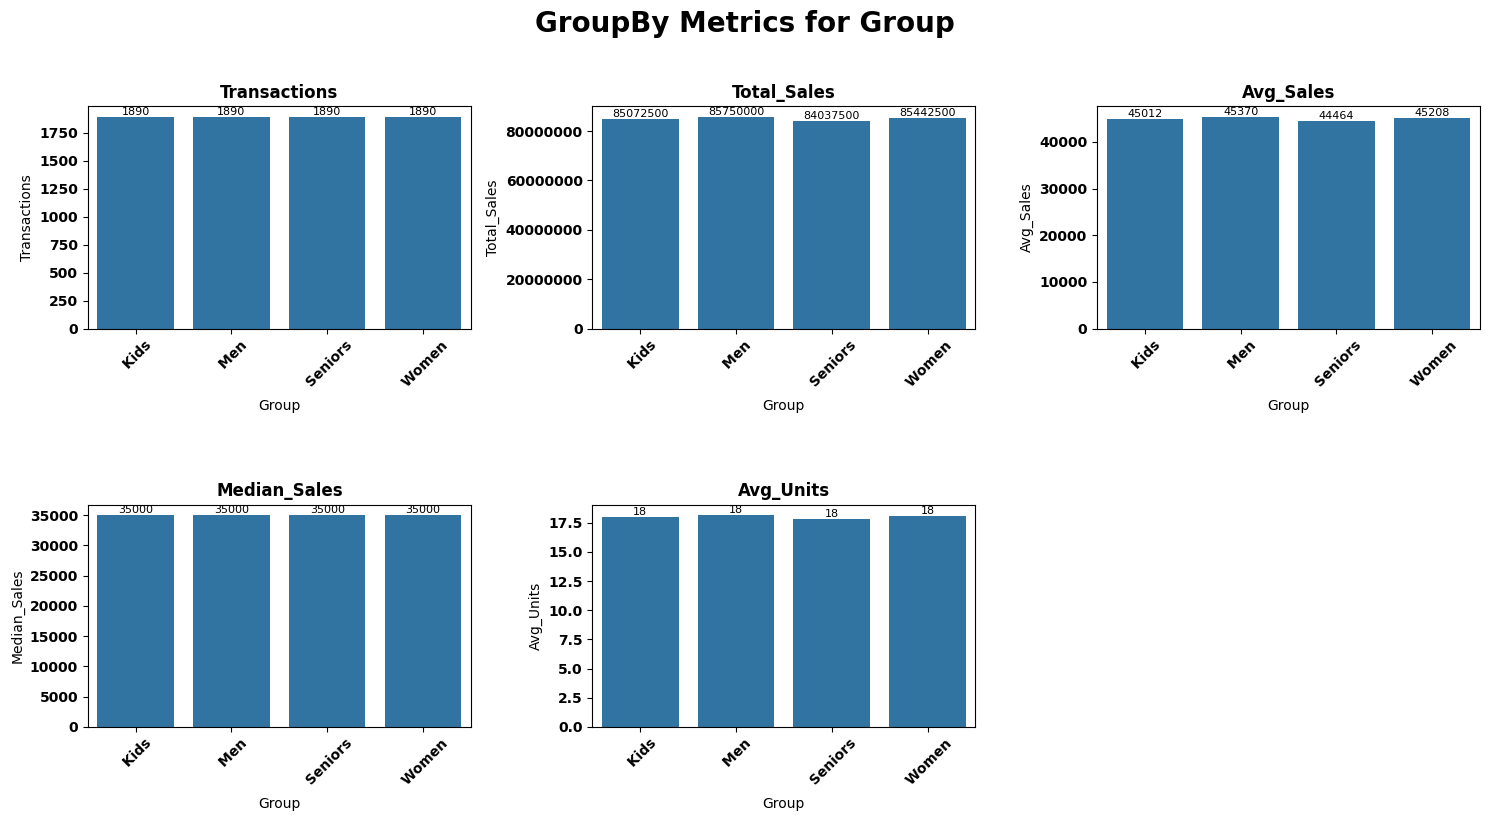

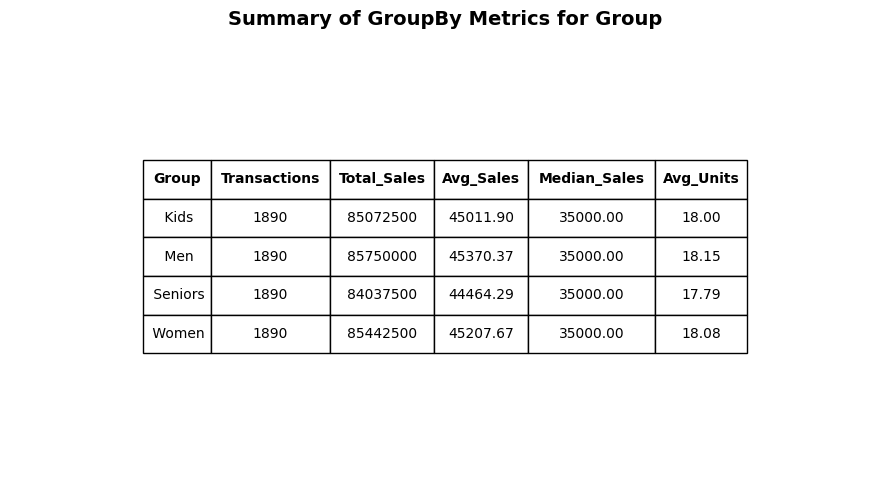

      Group  Total_Sales
1       Men     85750000
3     Women     85442500
0      Kids     85072500
2   Seniors     84037500


In [18]:
def DisplayGroupByMetricsPlots(df_target, target_label, plot_title): 
    
    # Get list of metrics we want to plot and drop feature label
    cols_to_plot = df_target.columns.tolist()

    if target_label is not None:
        cols_to_plot.remove(target_label)
    
    number_of_cols = len(cols_to_plot)

    ncols = min(number_of_cols, 3)  # max 3 per row, but no more than n
    nrows = (number_of_cols + ncols - 1) // ncols

    # I need a 3 column plot
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = axes.flatten()

    # Iterate over each numeric column and plot a historbram
    for i, col in enumerate(cols_to_plot):

        sns.barplot(data=df_target, 
					x=target_label, 
					y=col, 
					ax=axes[i])
		
        axes[i].set_title(f'{col}', fontweight='bold')
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].bar_label(axes[i].containers[0], fmt='%.0f', fontsize=8)

        # Tick labels in bold
        axes[i].tick_params(axis='both', labelsize=10)
        for label in axes[i].get_xticklabels() + axes[i].get_yticklabels():
            label.set_fontweight('bold')

        axes[i].ticklabel_format(style='plain', axis='y')

    # Hide the blank/empty graphs
    for i in range(number_of_cols, len(axes)):
        fig.delaxes(axes[i])

    # Make plots more readable and add space
    title = None
    if plot_title is not None:
        title = plot_title
    else:
        title = f'Histograms for Numeric Features of {data_set_name}'

    plt.suptitle(title, y=1.02, fontsize=20, fontweight='bold')
    plt.subplots_adjust(top=0.92)  

    plt.tight_layout(h_pad=5)
    plt.show()  

    print()
    print()

    DisplayTable(df_target, f'Summary of GroupBy Metrics for {target_label}')

#PrintDataFrameStatus(df_ausapparalsales_new)
df_ausapparalsales_groupby = df_ausapparalsales.copy(deep=True)

df_state_summary = df_ausapparalsales_groupby.groupby('State').agg(
                                                                Transactions=('Sales', 'count'),
                                                                Total_Sales=('Sales', 'sum'),
                                                                Avg_Sales=('Sales', 'mean'),
                                                                Median_Sales=('Sales', 'median'),
                                                                Avg_Units=('Unit', 'mean')
                                                            ).round(2).reset_index()
#print(df_state_summary)
DisplayGroupByMetricsPlots(df_state_summary, 'State', 'GroupBy Metrics for State') 
#PrintDataFrameStatus(df_state_summary)

# Analyze each customer group
df_group_summary = df_ausapparalsales_groupby.groupby('Group').agg(
                                                                Transactions=('Sales', 'count'),
                                                                Total_Sales=('Sales', 'sum'),
                                                                Avg_Sales=('Sales', 'mean'),
                                                                Median_Sales=('Sales', 'median'),
                                                                Avg_Units=('Unit', 'mean')
                                                            ).round(2).reset_index()

DisplayGroupByMetricsPlots(df_group_summary, 'Group', 'GroupBy Metrics for Group') 

print(df_group_summary[['Group', 'Total_Sales']].sort_values('Total_Sales', ascending=False))


##### **Analysis of GroupBy() for Data Chunking** #####
- For Sales:
    - Transactions equally distributed across all states
    - VIC, NSW, SA have the highest Total Sales, Average Sales, Median Sales and Average Units
    - This doesn't quite match up with the relative population sizes of the states

- For Groups
    - The distribution of sales aggregations across Groups are incredibly equaly distributed

- Groups Total Sales Ranked:
    - Men have the highest total sales
    - Seniors have the lowest total sales
    </br></br>
      **Group  Total_Sales**</br>
      Men           85750000</br>
      Women         85442500</br>
      Kids          85072500</br>
      Seniors       84037500</br>

##### **Use Data Chunking to Generate and Plot Weekly, Monthly and Quarterly Reports** #####

C:\Users\jxbma\AppData\Local\Temp\ipykernel_61992\1024479660.py:86: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_ausapparalsales_groupby['Date'] = pd.to_datetime(df_ausapparalsales_groupby['Date'])


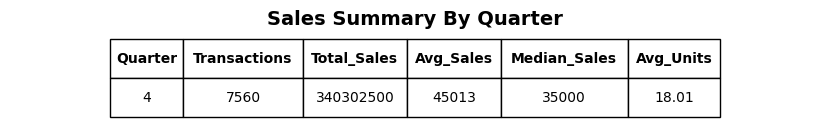

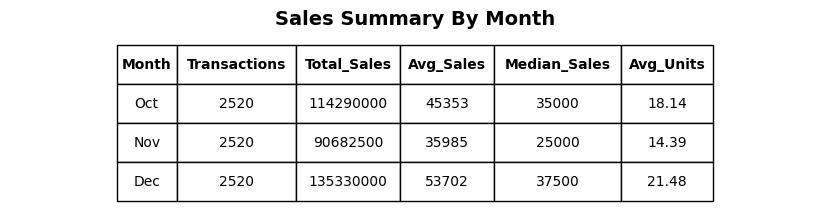

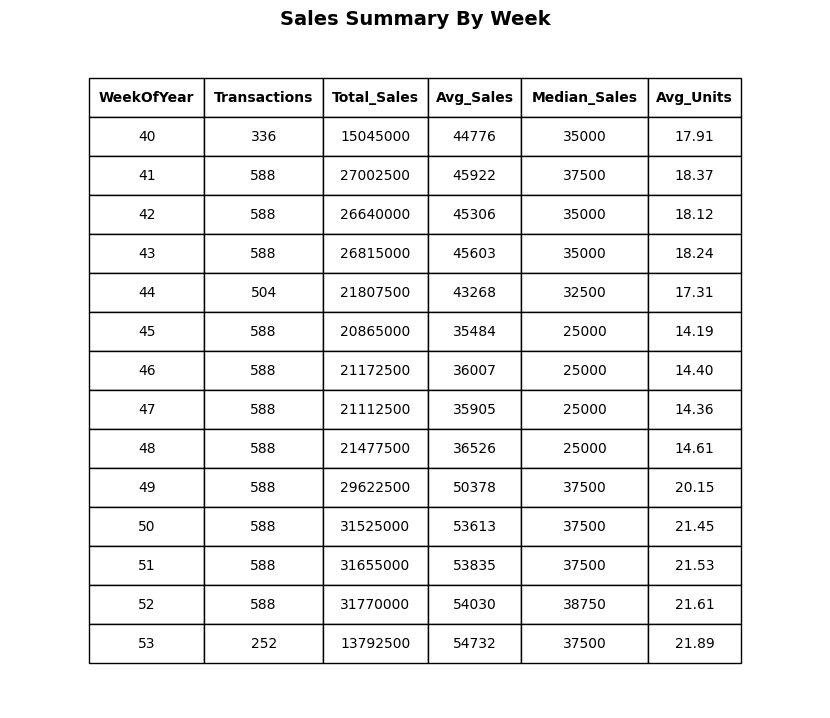

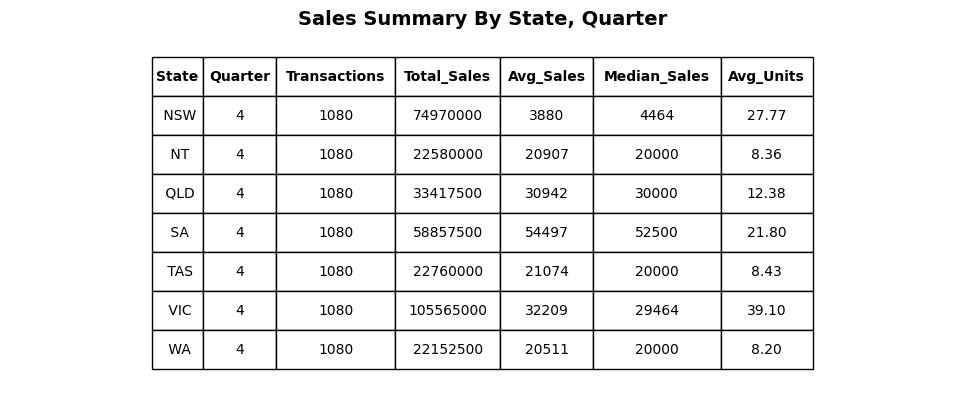

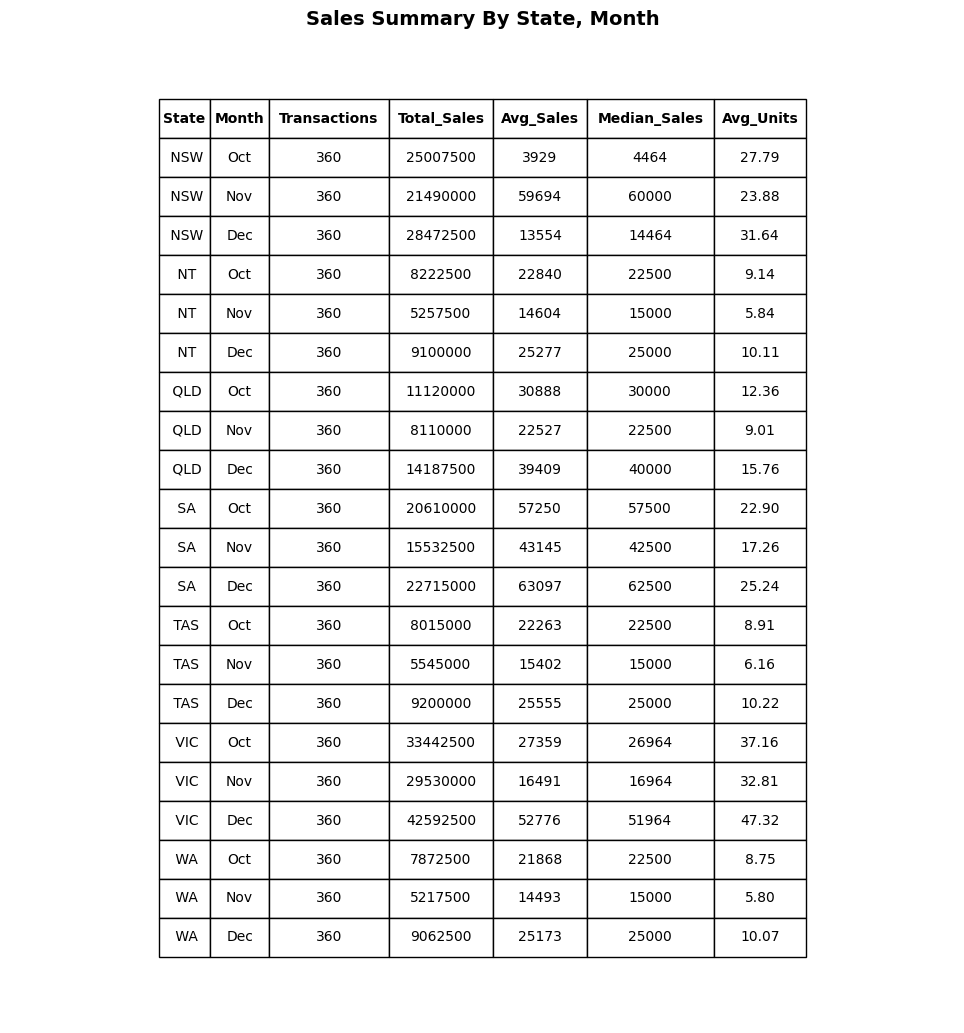

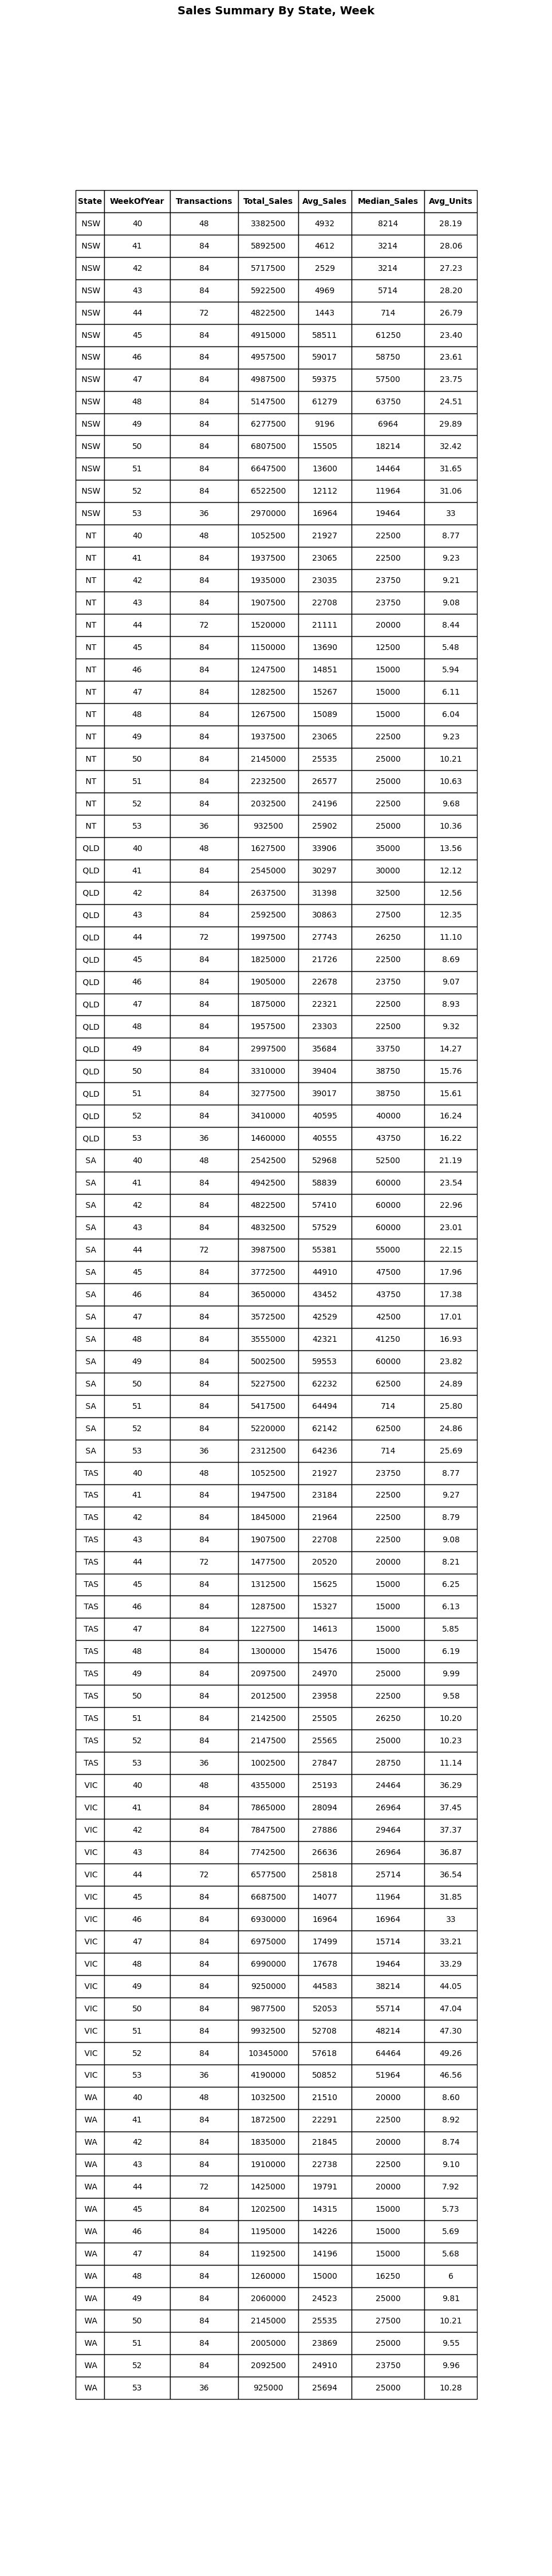

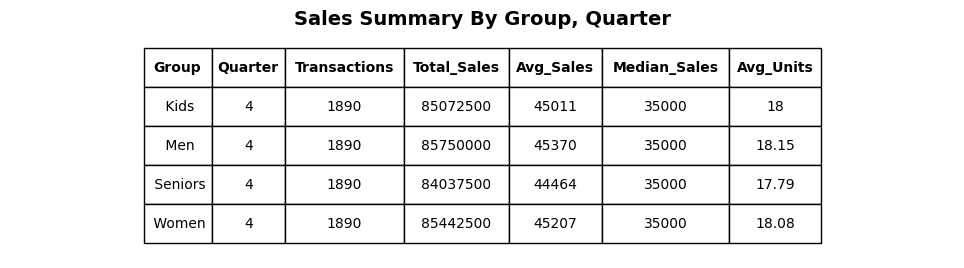

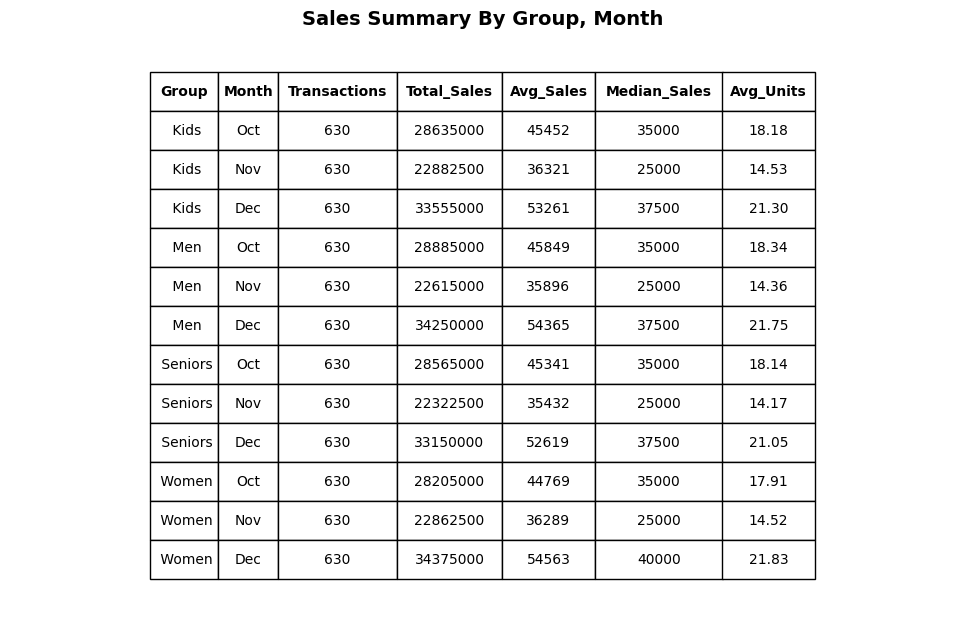

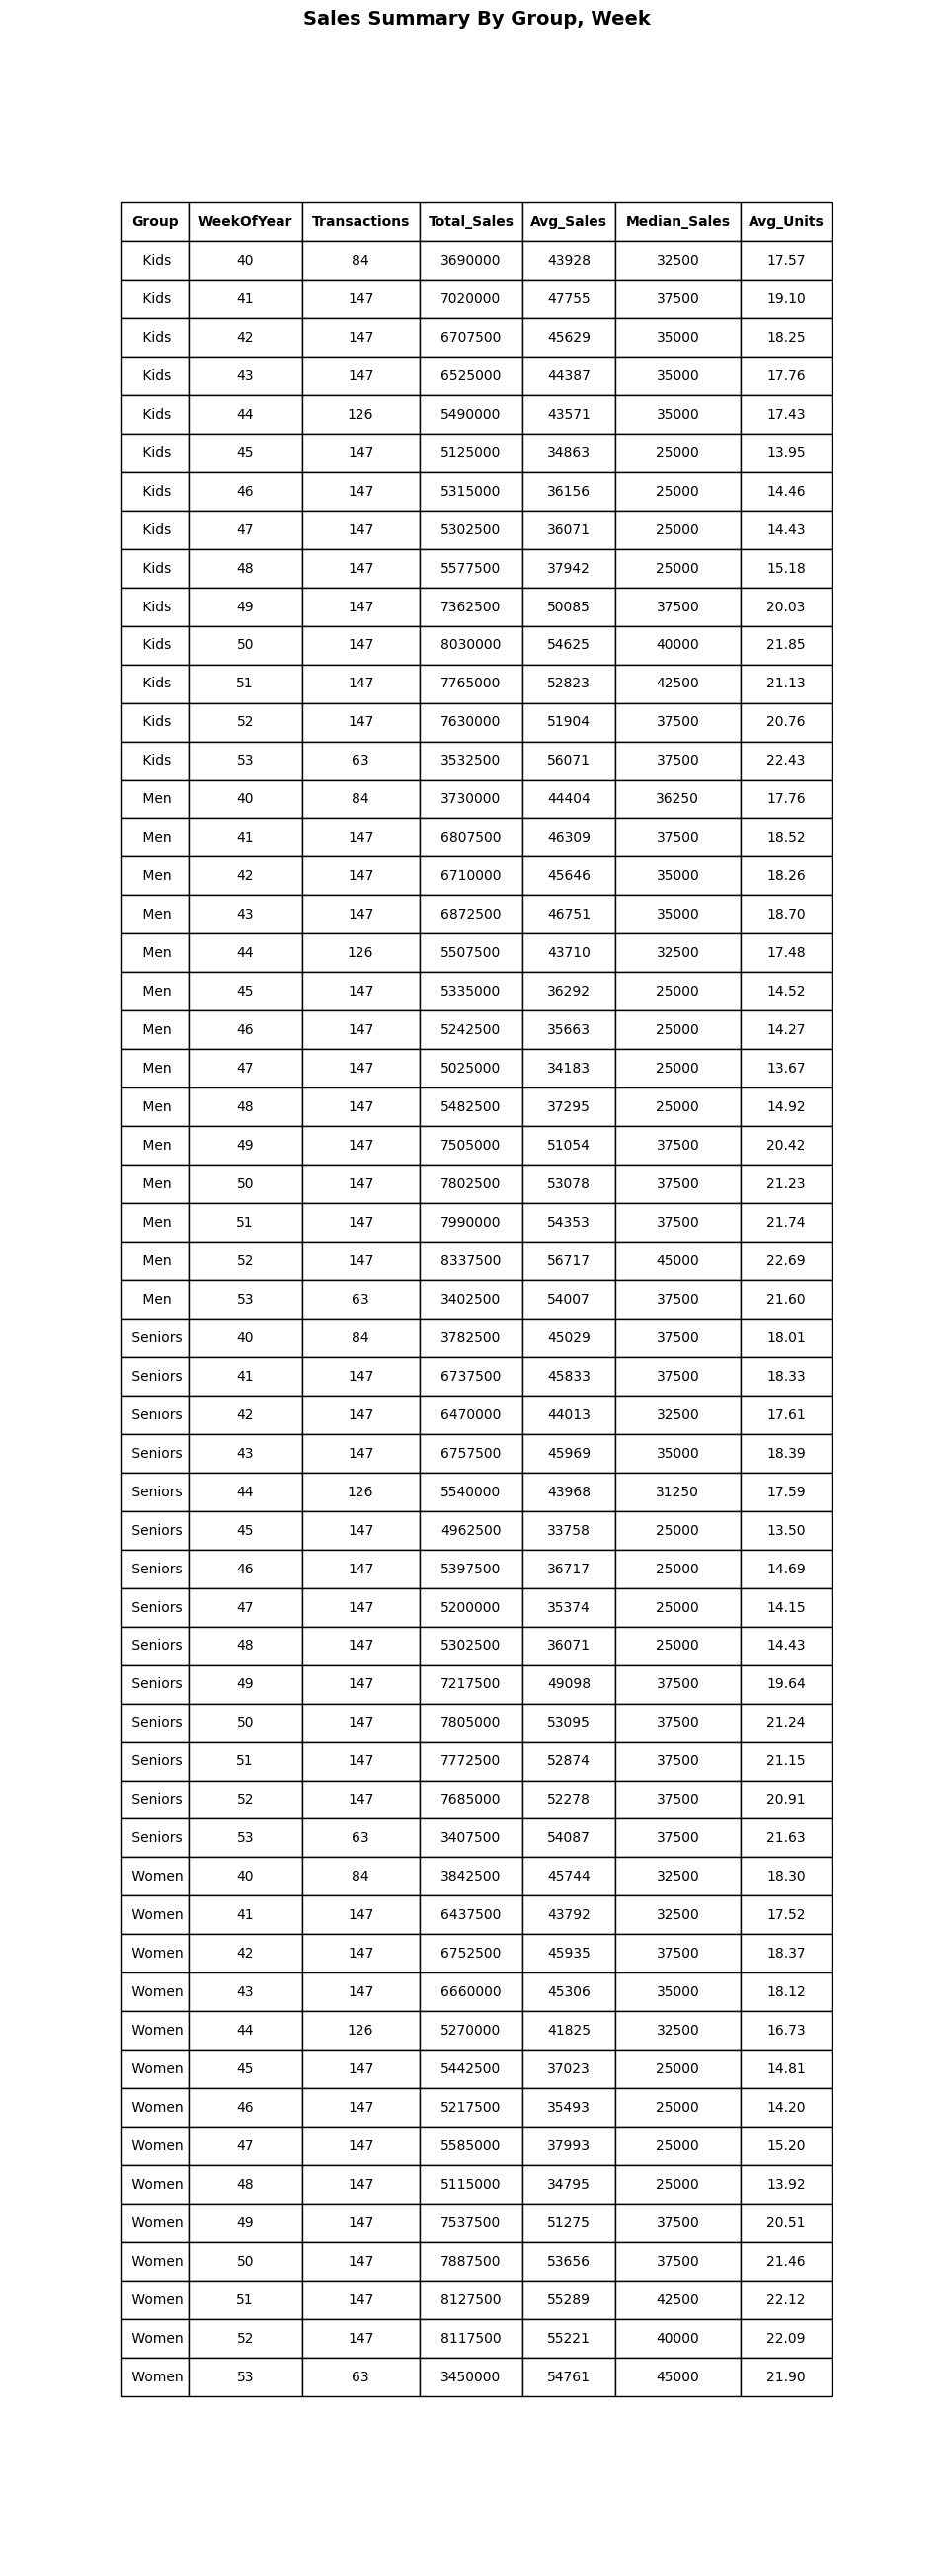


Reports Generation Comp



In [19]:
#
# Generate Weekly, Monthly, Quarterly Reports for Sales
# 

def CreatGroupBySummary(df_target, target_labels):
        df_summary = df_target.groupby(target_labels).agg(
                                                        Transactions=('Sales', 'count'),
                                                        Total_Sales=('Sales', 'sum'),
                                                        Avg_Sales=('Sales', 'mean'),
                                                        Median_Sales=('Sales', 'median'),
                                                        Avg_Units=('Unit', 'mean')
                                                        ).round(2).reset_index()
        return df_summary

def format_value(val):
    if isinstance(val, (int, np.integer)):
        return str(val)
    elif isinstance(val, (float, np.floating)):
        if val == int(val):  # whole number stored as float
            return str(int(val))
        else:
            return f'{val:.2f}'
    else:
        return str(val)
    
def DisplaySummaryTable(df_target, table_title=None):
    
    n_rows, n_cols = df_target.shape
    
    fig, ax = plt.subplots(figsize=(n_cols * 1.5, (n_rows + 1) * 0.5))  # reduced height
    ax.axis('off')

    cell_text = [[format_value(val) for val in row] for row in df_target.values]

    table = ax.table(
        cellText=cell_text,
        colLabels=df_target.columns,
        cellLoc='center',
        loc='center'
    )

    # Make column headers bold
    for col in range(n_cols):
        table[(0, col)].set_text_props(fontweight='bold')

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.auto_set_column_width(col=list(range(n_cols)))
    table.scale(1.2, 2.0)  # keep original

    if table_title is not None:
        plt.title(table_title, fontweight='bold', fontsize=14)
    
    plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05)  # reduce margins
    plt.show()

def DisplaySalesSummaryReport(df_target, title):

        columns = None

        # Convert Data Types
        if 'Quarter' in df_target.columns:
                columns = ['Quarter']
        # elif 'Month' in df_target.columns:
        #         columns = ['Month']        
        elif 'WeekOfYear' in df_target.columns:
                columns = ['WeekOfYear']                

        if columns is not None:
                df_target[columns] = df_target[columns].astype('int8')

        columns = ['Transactions']
        df_target[columns] = df_target[columns].astype('int16')

        columns = ['Avg_Sales', 'Median_Sales']
        df_target[columns] = df_target[columns].astype('uint16')

        columns = ['Total_Sales']
        df_target[columns] = df_target[columns].astype('uint32')

        #PrintDataFrameStatus(df_target)
        DisplaySummaryTable(df_target, title)


df_ausapparalsales_groupby = df_ausapparalsales.copy(deep=True)
df_ausapparalsales_groupby['Date'] = pd.to_datetime(df_ausapparalsales_groupby['Date'])

df_ausapparalsales_groupby = EncodeDateFeatures(df_ausapparalsales_groupby)

summary_reports = []

month_map = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
             7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}

# Sales Summaries by Quarter, Month, Week
df_sales_by_quarter_summary = CreatGroupBySummary(df_ausapparalsales_groupby, 'Quarter')
summary_reports.append({'Title':'Sales Summary By Quarter', 'Data':df_sales_by_quarter_summary})

df_sales_by_month_summary = CreatGroupBySummary(df_ausapparalsales_groupby, 'Month')
df_sales_by_month_summary['Month'] = df_sales_by_month_summary['Month'].map(month_map)
summary_reports.append({'Title':'Sales Summary By Month', 'Data':df_sales_by_month_summary})

df_sales_by_weekofyear_summary = CreatGroupBySummary(df_ausapparalsales_groupby, 'WeekOfYear')
summary_reports.append({'Title':'Sales Summary By Week', 'Data':df_sales_by_weekofyear_summary})

# Sales Summaries by State [Quarter, Month, Week]
df_sales_state_by_quarter_summary = CreatGroupBySummary(df_ausapparalsales_groupby, ['State','Quarter'])
summary_reports.append({'Title':'Sales Summary By State, Quarter', 'Data':df_sales_state_by_quarter_summary})

df_sales_state_by_month_summary = CreatGroupBySummary(df_ausapparalsales_groupby, ['State','Month'])
df_sales_state_by_month_summary['Month'] = df_sales_state_by_month_summary['Month'].map(month_map)
summary_reports.append({'Title':'Sales Summary By State, Month', 'Data':df_sales_state_by_month_summary})

df_sales_state_by_weekofyear_summary = CreatGroupBySummary(df_ausapparalsales_groupby, ['State','WeekOfYear'])
summary_reports.append({'Title':'Sales Summary By State, Week', 'Data':df_sales_state_by_weekofyear_summary})

# Sales Summaries by Group [Quarter, Month, Week]
df_sales_group_by_quarter_summary = CreatGroupBySummary(df_ausapparalsales_groupby, ['Group','Quarter'])
summary_reports.append({'Title':'Sales Summary By Group, Quarter', 'Data':df_sales_group_by_quarter_summary})

df_sales_group_by_month_summary = CreatGroupBySummary(df_ausapparalsales_groupby, ['Group','Month'])
df_sales_group_by_month_summary['Month'] = df_sales_group_by_month_summary['Month'].map(month_map)
summary_reports.append({'Title':'Sales Summary By Group, Month', 'Data':df_sales_group_by_month_summary})

df_sales_by_weekofyear_summary = CreatGroupBySummary(df_ausapparalsales_groupby, ['Group','WeekOfYear'])
summary_reports.append({'Title':'Sales Summary By Group, Week', 'Data':df_sales_by_weekofyear_summary})

#PrintDataFrameStatus(df_sales_group_by_quarter_summary)

# Iterate and display tables
for report in summary_reports:
    DisplaySalesSummaryReport(report['Data'], report['Title'])

print('=======================================================================')
print()
print('Reports Generation Comp')
print()
print('=======================================================================')

### **Final Thoughts and Recap** ###
#### Initial load and EDA analysis uncovering the following initial observations: ####
    - On initial examination, the data did not contain any instances of missing values.
    - I did notice that the string (type object) columns contained leading spaces and needed to be trimmed.
    - Examining the statistics, **Unit** and **Sales** features appeared to have values within reasonable ranges.
    - I recoginized the relationship between the **Unit** and **Sales** features.
      I checked this relationship for consitency througout the dataset.
        Based on the relationship between Sales and Units
                    - 1 unit = $2500 in sales
                        - 8 units = $20000
                        - 4 units = $10000
                        - 2 units - $5000
    - I plotted distributions (via histograms and boxplots) of the original raw data and found **Unit** and **Sales** 
      to be heavily right skewed. 
    - I investigated possible transforms to potentially normalize the data distributions and settled on Yeo-Johnson for both.
      I ran StandardScaler, Yeo-Johnson, Cox-Box transformations and compared the results.
      Yeo-Johnson gave the best results.

#### Data Wrangling ####
##### Fix Missing Data #####
    Upon testing, I did not uncover any instances if missing, empty, blank, nan data.
##### Address Invalid Data #####
    **Group** and **State** are 2 categorical variables with predefined values (in a sense enumerated values).
    I verified by looking at the collection of unique values for each feature that there were no bad values/outliers/empty strings.
##### Mitigate the effect of extreme outliers #####
    I did not see any extreme outliers on the initial dataset, so mitigation was performed.
##### Additional Data Fixes #####
    None required.
#### Feature Engineering ####
##### Binning Exploration #####
    Examined the strategy of binning the data would work on any of the features.
    Sales was binned into 5 bins with the following categories (Sales: low->low-middle=>middle->high-middle=>high)
    I plotted the results in a CountPlot to get a better understanding of the data trend.
    The majority of the sales were categorized as **Low**.
    There was a sharp decline from **Low** to **Low-Middle** (4004 -> 1825).
    The decline continued steadly through **High** sales values.
    Here are the results:
                Low             =>   4004 
                Low-Middle      =>   1825
                Middle          =>   1147
                Middle-High     =>   452
                High            =>   132
##### Data Encoding #####
    I performed One-Hot Encoding (), Ordinal Encoding() but no Label Encoding()
        State =>     One-Encoded
        Group =>     One-Encoded
        TimeOfDay => Ordinal-Encoded
##### Wrangling of Date features #####
    For purposes of **EDA** and future model use, I split the date field into smaller, more interesting units.
    First the **Date** field was converted from a string to an actual type of Date.
    Date was split into:
                Month               int32 
                DayOfWeek           int32 
                Day                 int32 
                WeekOfYear          UInt32
                Weekend             int64         
##### Data Type Conversion #####
    Larger integer and float types to appropriate integers for overall model performance improvements
    Here are is the list of features that were type converted:
        Unit                int64          ==> int8
        Sales               int64          ==> int32
        Month               int32          ==> int8
        DayOfWeek           int32          ==> int8
        Day                 int32          ==> int16
        WeekOfYear          UInt32         ==> int8
        Weekend             int64          ==> int8
##### GroupBy() => Chunking and Merging #####
    Data **Chunking** was used to generate and lot **Weekly, Monthly and Quarterly** Reports.
    It was applied to the following combinations:
        - Sales Summaries by Quarter, Month, Week
        - Sales Summaries by State [Quarter, Month, Week]
        - Sales Summaries by Group [Quarter, Month, Week]
    This was useful in providing more detailed insight across [Quarter, Month, Week] periods
    for Quarter, State and Group. 
    This dataset only included 1 quarters worth of data, but should it expanded to include one
    or multi-years worth of data, it will reveal more meaningful insights.
    I did not perform any **Merging**, as that is a process more suitable towards creation/optimzation of model development.
##### Create Combined Feature Columns #####
    No combined features were created.
##### Polynomial Feature Creation #####
    Polynomial Feature Creation were not part of the requirements.
##### Feature Distribution Normalization #####
    Based on EDA, I determined that Yeo-Johnson transformation for normalization was the best option.
    I saved those results to the dataset.
##### Feature Scaling #####
    I did not apply scaling as it was not part of the requirements.
### Last Refections ###
    The data was clearly not real world data as a lot of it was incredibly uniformly distributed.
    It smelled of manufacture/test data as in a real world the values could not be so close (in some cases identical)
    across different categories.

    A majority of the time (80%) was spent working through EDA to gain a deeper understanding of its trends.
    As I continue with this process, it will become much more efficient as I will be reusing tools, patterns and techniques
    that I've discovered along the way.

    This investigation (as evidenced by the notebook) is much more organized. I feel I've stil got a ways to go as I refine the process.
    The struggle is really to "do what" and "where to do it", document it in the correct sequence of events.
    This will only get better through time, practice, mistakes and corrections.
#### Interesting Side Note ####
    In the early 90s I actually rearchitected the charting package at Lotus Development for use (primarily) in Lotus 1-2-3.
    It became a shared component that was used throughout Lotus's product suite.
    Now over 30 years later, I'm actually using charts/plots to do data analysis and do interesting these.
    I wrote it, but never really used it. Kind of like being the president, but not a client of the Hair Club for Men.
